# Rossegger Green-function calculation for the sPHENIX TPC

## Purpose

This notebook implements the analytical Green-function strategy for space-charge calculations in a coaxial Time Projection Chamber. It is written as a self-contained teaching and production notebook for the sPHENIX TPC geometry.

The calculation follows the mathematical structure of Chapter 5 of Stefan Rossegger's thesis, but the explanations below are newly written and adapted to the sPHENIX geometry.

The notebook performs four connected tasks:

1. Define a three-dimensional positive-ion density $\rho(r,\phi,z)$.
2. Construct the Green function of a grounded coaxial cylindrical cavity.
3. Convolve that Green function with the charge density to obtain
   $$
   E_r(r,\phi,z),\qquad E_\phi(r,\phi,z),\qquad E_z(r,\phi,z).
   $$
4. Write three independent ROOT files:
   - a sampled full Green-function array,
   - complete three-dimensional charge and electric-field maps,
   - axisymmetric two-dimensional maps in the exact structure used by PHGarfield.

By default, all azimuthal modulations are zero:

$$
\rho(r,\phi,z)=\rho(r,z).
$$

So only the $m=0$ Fourier mode survives and

$$
E_\phi=0.
$$

The code nevertheless retains the full Fourier machinery. Nonzero $\phi$ modulation can be enabled through the configuration cell without rewriting the solver.

Default QA is intentionally restricted to $r$-$z$ plots. Azimuthal QA is available but disabled by default.

## 1. Physical motivation

A TPC reconstructs a charged particle from electrons drifting through gas toward a readout plane. In the ideal detector, the drift field is nearly uniform and points along $z$. In a high-rate environment, slowly moving positive ions accumulate in the gas. Their electric field adds a position-dependent perturbation,

$$
\mathbf E_{\rm total}
=
\mathbf E_{\rm nominal}
+
\delta\mathbf E_{\rm space\ charge}.
$$

The perturbation changes the electron drift velocity. In a magnetic field, even a purely radial electric-field perturbation can generate both radial and azimuthal electron displacement.

This notebook stops at the electrostatic step:

$$
\rho
\longrightarrow
\delta\Phi
\longrightarrow
\delta\mathbf E.
$$

Garfield later combines the calculated field with the gas transport properties and magnetic field to determine electron trajectories.

### Electrostatic equation

The perturbing potential satisfies Poisson's equation,

$$
\nabla^2\delta\Phi
=
-\frac{\rho}{\epsilon_0}.
$$

The field is

$$
\delta\mathbf E
=
-\nabla\delta\Phi.
$$

The sPHENIX TPC drift region is approximated as a grounded coaxial cavity,

$$
a<r<b,\qquad 0<z<L,\qquad 0\leq\phi<2\pi.
$$

The perturbing potential obeys homogeneous Dirichlet boundary conditions,

$$
\delta\Phi(a,\phi,z)=0,\qquad
\delta\Phi(b,\phi,z)=0,
$$

$$
\delta\Phi(r,\phi,0)=0,\qquad
\delta\Phi(r,\phi,L)=0.
$$

The physical inner field cage is at $a=20\ \mathrm{cm}$. The positive-ion source begins near $21\ \mathrm{cm}$, but that source edge is not an electrostatic boundary.

## 2. Green-function idea

A Green function is the response of the cavity to a unit point source. We distinguish:

- observation coordinates:
$$
(r,\phi,z);
$$
- source coordinates:
$$
(r',\phi',z').
$$

The full scalar Green function is therefore

$$
G(r,\phi,z;r',\phi',z').
$$

It satisfies

$$
-\nabla^2 G
=
\frac{\delta(r-r')\delta(\phi-\phi')\delta(z-z')}{r}
$$

together with the same grounded boundary conditions as the perturbing potential.

Once $G$ is known, an arbitrary charge cloud is handled by superposition:

$$
\delta\Phi(r,\phi,z)
=
\frac{1}{\epsilon_0}
\int_a^b r'\,dr'
\int_0^{2\pi}d\phi'
\int_0^L dz'\,
\rho(r',\phi',z')
G(r,\phi,z;r',\phi',z').
$$

The electric field is obtained by differentiating with respect to the observation coordinates:

$$
E_r=-\frac{\partial\Phi}{\partial r},
\qquad
E_\phi=-\frac{1}{r}\frac{\partial\Phi}{\partial\phi},
\qquad
E_z=-\frac{\partial\Phi}{\partial z}.
$$

The key numerical advantage is linearity. The expensive geometry-dependent response can be separated from the chosen charge density.

## 3. Separation into cylindrical eigenmodes

The coaxial geometry allows the Green function to be expanded in orthogonal modes:

- Fourier modes in $\phi$;
- sine modes in $z$;
- Bessel eigenfunctions in $r$.

The azimuthal functions are

$$
1,\qquad \cos(m\phi),\qquad \sin(m\phi),
$$

with integer $m\geq0$.

The longitudinal functions are

$$
Z_l(z)=\sin(q_lz),
\qquad
q_l=\frac{l\pi}{L},
\qquad l=1,2,\ldots
$$

which vanish automatically at $z=0$ and $z=L$.

For each azimuthal order $m$, define the radial eigenfunction

$$
R_{mn}(r)
=
J_m(k_{mn}r)Y_m(k_{mn}a)
-
Y_m(k_{mn}r)J_m(k_{mn}a).
$$

It vanishes at $r=a$. The eigenvalue $k_{mn}$ is chosen so that it also vanishes at $r=b$:

$$
R_{mn}(b)=0.
$$

The radial normalization is

$$
N_{mn}^2
=
\int_a^b r\,R_{mn}^2(r)\,dr.
$$

The longitudinal normalization is

$$
N_l^2
=
\int_0^L\sin^2(q_lz)\,dz
=
\frac{L}{2}.
$$

The full modal Green function used in this notebook is

$$
G(r,r',z,z',\phi,\phi')=
\sum_{m=0}^{\infty}
\sum_{n=1}^{\infty}
\sum_{l=1}^{\infty}
\frac{2-\delta_{m0}}{2\pi}
\cos[m(\phi-\phi')]
\frac{R_{mn}(r)R_{mn}(r')}{N_{mn}^2}
\frac{2}{L}
\frac{\sin(q_lz)\sin(q_lz')}
{k_{mn}^2+q_l^2}.
$$

This is an eigenfunction representation of the same grounded-cavity Green function discussed by Rossegger. The image-term form and the closed hyperbolic forms are alternative reorganizations of the same solution.

The sums are infinite mathematically. The code truncates them at configurable values $m_{\max}$, $N_r$, and $N_z$. Convergence QA checks whether those truncations are adequate.

In [1]:
# ============================================================
# Imports
# ============================================================

import json
import math
import time
from pathlib import Path

import numpy as np
import ROOT as root

from numpy.polynomial.legendre import leggauss
from scipy import integrate, optimize, special
from joblib import Parallel, delayed, parallel_config
from IPython.display import display, Image

root.gROOT.SetBatch(True)
root.gStyle.SetOptStat(0)
root.gStyle.SetNumberContours(80)

EPSILON_0 = 8.8541878128e-12  # F/m
CM_TO_M = 1.0e-2
M_TO_CM = 100.0

Welcome to JupyROOT 6.30/06


In [ ]:
# ============================================================
# User configuration
# ============================================================

# Physical electrostatic cavity
A_CM = 20.0
B_CM = 75.911
L_CM = 102.325

A_CM = 21.6
B_CM = 76.4
L_CM = 102.325

A_CM = 21.78
B_CM = 76.28
L_CM = 102.325

# Positive-ion source support
SOURCE_R_MIN_CM = 20.01
SOURCE_R_MAX_CM = 75.911

SOURCE_R_MIN_CM = 22.8
SOURCE_R_MAX_CM = 75.43

SOURCE_R_MIN_CM = 22.2
SOURCE_R_MAX_CM = 75.84


# Reference volume-averaged density
RHO_REFERENCE_NC_PER_M3 = 20.0
K_EFF = 1.0
RADIAL_POWER_ALPHA = 1.4  # rho(r) proportional to 1/r^alpha

# Optional phi modulation:
# rho -> rho * [1 + A1 cos(phi-phase1) + A12 cos(12(phi-phase12))]
M1_AMPLITUDE = 0.0
M1_PHASE = 0.0
M12_AMPLITUDE = 0.0
M12_PHASE = 0.0

# Source grid
NR_SOURCE = 18
NPHI_SOURCE = 24
NZ_SOURCE = 20

# Observation field grid
NR_OBS = 24
NPHI_OBS = 24
NZ_OBS = 28

# Modal truncation
M_PHI_MAX = 4
N_RADIAL_MODES = 18
N_LONGITUDINAL_MODES = 22

# Multiprocessing for production field evaluation
N_WORKERS = 12

# If all phi amplitudes are zero, only m=0 is computed.
AUTO_AXISYMMETRIC = True

# QA
DO_QA = True
DO_PHI_QA = False
DO_CONVERGENCE_QA = True
DO_GAUSS_QA = True

# Sampled full Green-function array.
# This is intentionally coarser than the production field grid.
N_GREEN_R_OBS = 20
N_GREEN_PHI_OBS = 6
N_GREEN_Z_OBS = 20
N_GREEN_R_SRC = 20
N_GREEN_PHI_SRC = 6
N_GREEN_Z_SRC = 20

# Outputs
GREEN_ROOT_FILE = "sphenix_rossegger_green_function.root"
FIELD3D_ROOT_FILE = "sphenix_rossegger_fields_3d.root"
GARFIELD_ROOT_FILE = "sphenix_rossegger_garfield_field_1p4.root"
QA_DIRECTORY = Path("rossegger_qa")
QA_DIRECTORY.mkdir(exist_ok=True)

VERIFY_ROOT_OUTPUT = True

In [3]:
# ============================================================
# Derived geometry and grids
# ============================================================

a = A_CM * CM_TO_M
b = B_CM * CM_TO_M
L = L_CM * CM_TO_M

source_r_min = SOURCE_R_MIN_CM * CM_TO_M
source_r_max = SOURCE_R_MAX_CM * CM_TO_M

if not (0.0 < a < source_r_min < source_r_max <= b):
    raise ValueError("Require 0 < a < source_r_min < source_r_max <= b.")

phi_is_uniform = (
    abs(M1_AMPLITUDE) < 1e-15
    and abs(M12_AMPLITUDE) < 1e-15
)

M_PHI_EFFECTIVE_MAX = (
    M_PHI_MAX if (AUTO_AXISYMMETRIC and phi_is_uniform) else M_PHI_MAX
)

r_src_edges = np.linspace(source_r_min, source_r_max, NR_SOURCE + 1)
phi_src_edges = np.linspace(0.0, 2.0*np.pi, NPHI_SOURCE + 1)
z_src_edges = np.linspace(0.0, L, NZ_SOURCE + 1)

r_src = 0.5*(r_src_edges[:-1] + r_src_edges[1:])
phi_src = 0.5*(phi_src_edges[:-1] + phi_src_edges[1:])
z_src = 0.5*(z_src_edges[:-1] + z_src_edges[1:])

r_obs_edges = np.linspace(a, b, NR_OBS + 1)
phi_obs_edges = np.linspace(0.0, 2.0*np.pi, NPHI_OBS + 1)
z_obs_edges = np.linspace(0.0, L, NZ_OBS + 1)

r_obs = 0.5*(r_obs_edges[:-1] + r_obs_edges[1:])
phi_obs = 0.5*(phi_obs_edges[:-1] + phi_obs_edges[1:])
z_obs = 0.5*(z_obs_edges[:-1] + z_obs_edges[1:])

dr_src = np.diff(r_src_edges)
dphi_src = np.diff(phi_src_edges)
dz_src = np.diff(z_src_edges)

source_cell_volumes = (
    0.5*(r_src_edges[1:]**2-r_src_edges[:-1]**2)[:, None, None]
    * dphi_src[None, :, None]
    * dz_src[None, None, :]
)

print("Physical cavity:")
print(f"  a = {A_CM:.3f} cm")
print(f"  b = {B_CM:.3f} cm")
print(f"  L = {L_CM:.3f} cm")
print("Source support:")
print(f"  {SOURCE_R_MIN_CM:.3f} <= r <= {SOURCE_R_MAX_CM:.3f} cm")
print("Effective azimuthal order:", M_PHI_EFFECTIVE_MAX)

Physical cavity:
  a = 21.600 cm
  b = 76.400 cm
  L = 102.325 cm
Source support:
  22.800 <= r <= 75.430 cm
Effective azimuthal order: 4


## 4. Charge-density model

The baseline radial profile is

$$
\rho(r)\propto \frac{1}{r^\alpha},
$$

with default $\alpha=1$.

Why is $1/r$ natural? The cylindrical volume of an annulus with width $dr$ is proportional to $r\,dr$. Therefore,

$$
\rho(r)\propto\frac{1}{r}
$$

produces approximately equal charge in equal-width radial annuli.

The optional azimuthal modulation is

$$
f_\phi(\phi)
=
1
+
A_1\cos(\phi-\phi_1)
+
A_{12}\cos[12(\phi-\phi_{12})].
$$

By default,

$$
A_1=A_{12}=0,
$$

so the density is axisymmetric.

The final density is normalized so that its volume-weighted mean over the charged region equals

$$
K_{\rm eff}\times 20\ \mathrm{nC/m^3}.
$$

Thus the shape and normalization are controlled separately.

In [4]:
# ============================================================
# Build and normalize rho(r, phi, z)
# ============================================================

R3 = r_src[:, None, None]
P3 = phi_src[None, :, None]
Z3 = z_src[None, None, :]

radial_shape = (source_r_min / R3)**RADIAL_POWER_ALPHA

phi_shape = (
    1.0
    + M1_AMPLITUDE*np.cos(P3-M1_PHASE)
    + M12_AMPLITUDE*np.cos(12.0*(P3-M12_PHASE))
)

if np.min(phi_shape) < 0.0:
    raise ValueError("Phi modulation makes rho negative.")

z_shape = np.ones_like(Z3)

raw_shape = radial_shape * phi_shape * z_shape
target_mean_rho = K_EFF * RHO_REFERENCE_NC_PER_M3 * 1e-9

shape_mean = np.sum(raw_shape*source_cell_volumes)/np.sum(source_cell_volumes)
rho = target_mean_rho * raw_shape/shape_mean

Q_total = np.sum(rho*source_cell_volumes)
N_ions = Q_total/1.602176634e-19

print(f"Volume-weighted mean rho = {np.sum(rho*source_cell_volumes)/np.sum(source_cell_volumes):.6e} C/m^3")
print(f"Total charge, one side   = {Q_total:.6e} C")
print(f"Equivalent unit ions     = {N_ions:.6e}")

Volume-weighted mean rho = 2.000000e-08 C/m^3
Total charge, one side   = 3.323833e-08 C
Equivalent unit ions     = 2.074573e+11


## 5. Radial eigenfunctions and why we solve for special values of \(k\)

The electric potential inside the TPC is expanded in a set of basis functions.  
Because the detector is cylindrical, the radial part of those basis functions is built from Bessel functions.

For a fixed azimuthal order \(m\), the radial equation has two independent solutions:

$$
J_m(kr)
$$

and

$$
Y_m(kr).
$$

Here:

- \(r\) is the radial position inside the TPC;
- \(m\) describes the angular structure in \(\phi\);
- \(k\) controls how rapidly the radial mode changes with \(r\).

A general radial solution is therefore a linear combination of \(J_m(kr)\) and \(Y_m(kr)\).

### Step 1: force the mode to vanish at the inner field cage

The perturbing potential must be zero at the inner conducting boundary,

$$
r=a.
$$

We therefore define

$$
R_m(k,r)
=
J_m(kr)Y_m(ka)
-
Y_m(kr)J_m(ka).
$$

This combination is chosen because at \(r=a\),

$$
R_m(k,a)
=
J_m(ka)Y_m(ka)
-
Y_m(ka)J_m(ka)
=
0.
$$

So the inner boundary condition is automatically satisfied for every value of \(k\).

### Step 2: require the same mode to vanish at the outer field cage

The perturbing potential must also be zero at

$$
r=b.
$$

Therefore we need

$$
R_m(k,b)=0.
$$

Substituting \(r=b\),

$$
R_m(k,b)
=
J_m(kb)Y_m(ka)
-
Y_m(kb)J_m(ka).
$$

We define

$$
F_m(k)
=
J_m(kb)Y_m(ka)
-
Y_m(kb)J_m(ka).
$$

The allowed values of \(k\) are the roots of

$$
F_m(k)=0.
$$

These special values are written as

$$
k_{mn},
$$

where:

- \(m\) labels the azimuthal order;
- \(n=1,2,3,\ldots\) labels the different radial roots.

Each root gives one radial eigenfunction,

$$
R_{mn}(r)
=
R_m(k_{mn},r).
$$

Therefore,

$$
R_{mn}(a)=0
$$

and

$$
R_{mn}(b)=0.
$$

This means that every radial basis function already obeys both conducting field-cage boundaries.

### Physical picture

The situation is similar to standing waves on a string fixed at both ends.

For a string, only certain wavelengths fit between the two fixed endpoints.

Here, only certain values of \(k\) produce a radial Bessel-function shape that is zero at both

$$
r=a
$$

and

$$
r=b.
$$

The first root gives the smoothest radial mode. Higher roots produce modes with more radial oscillations.

### What the code does

For each value of \(m\), the code:

1. scans through possible values of \(k\);
2. evaluates \(F_m(k)\);
3. finds intervals where \(F_m(k)\) changes sign;
4. uses Brent's numerical root finder to determine the root accurately;
5. stores the roots as
   $$
   k_{m1},k_{m2},k_{m3},\ldots
   $$

The code then constructs the corresponding radial modes

$$
R_{m1}(r),R_{m2}(r),R_{m3}(r),\ldots
$$

and uses them to expand the Green function and electric field.

### Boundary-condition QA

After finding the roots, we verify numerically that

$$
R_{mn}(a)\approx0
$$

and

$$
R_{mn}(b)\approx0.
$$

The values are not exactly zero because of finite floating-point precision and numerical root-finding tolerance.

Small residuals confirm that the radial modes satisfy the physical inner and outer field-cage boundaries correctly.

In [5]:
# ============================================================
# Radial eigenfunctions, derivatives, roots, and norms
# ============================================================

def radial_boundary_function(k, m):
    return (
        special.jv(m, k*b)*special.yv(m, k*a)
        - special.yv(m, k*b)*special.jv(m, k*a)
    )

def radial_basis(k, m, r):
    return (
        special.jv(m, k*r)*special.yv(m, k*a)
        - special.yv(m, k*r)*special.jv(m, k*a)
    )

def radial_basis_derivative(k, m, r):
    return k*(
        special.jvp(m, k*r, 1)*special.yv(m, k*a)
        - special.yvp(m, k*r, 1)*special.jv(m, k*a)
    )

def find_radial_roots(m, n_roots):
    roots = []
    # Asymptotic spacing is approximately pi/(b-a).
    step = 0.20*np.pi/(b-a)
    k_left = max(1e-6, 0.10*np.pi/(b-a))
    f_left = radial_boundary_function(k_left, m)

    max_k = (n_roots + m + 20)*np.pi/(b-a)
    k = k_left + step

    while k <= max_k and len(roots) < n_roots:
        f = radial_boundary_function(k, m)
        if np.isfinite(f_left) and np.isfinite(f) and f_left*f < 0.0:
            root_value = optimize.brentq(
                radial_boundary_function,
                k-step,
                k,
                args=(m,),
                xtol=1e-12,
                rtol=1e-12
            )
            if not roots or abs(root_value-roots[-1]) > 1e-8:
                roots.append(root_value)
        k_left = k
        f_left = f
        k += step

    if len(roots) != n_roots:
        raise RuntimeError(
            f"Found {len(roots)} roots for m={m}; requested {n_roots}."
        )
    return np.array(roots)

k_modes = {}
radial_norms = {}

xg_norm, wg_norm = leggauss(192)
rr_norm = 0.5*(b-a)*xg_norm + 0.5*(b+a)
jac_norm = 0.5*(b-a)

for m in range(M_PHI_EFFECTIVE_MAX + 1):
    k_modes[m] = find_radial_roots(m, N_RADIAL_MODES)
    radial_norms[m] = np.array([
        jac_norm*np.sum(
            wg_norm*rr_norm*radial_basis(k, m, rr_norm)**2
        )
        for k in k_modes[m]
    ])

    max_a = max(abs(radial_basis(k, m, a)) for k in k_modes[m])
    max_b = max(abs(radial_basis(k, m, b)) for k in k_modes[m])
    print(
        f"m={m}: max |R(a)|={max_a:.3e}, "
        f"max |R(b)|={max_b:.3e}"
    )

q_modes = np.arange(1, N_LONGITUDINAL_MODES+1)*np.pi/L

m=0: max |R(a)|=0.000e+00, max |R(b)|=1.909e-13
m=1: max |R(a)|=0.000e+00, max |R(b)|=1.563e-13
m=2: max |R(a)|=0.000e+00, max |R(b)|=2.027e-13
m=3: max |R(a)|=0.000e+00, max |R(b)|=1.028e-13
m=4: max |R(a)|=0.000e+00, max |R(b)|=3.340e-13


## 6. Expanding the charge distribution in the detector eigenmodes

After constructing the allowed spatial modes of the cylindrical TPC, the next step is to determine how strongly the actual ion distribution excites each one.

The charge density

$$
\rho(r',\phi',z')
$$

is generally not equal to a single eigenmode. Instead, it is written as a sum of many radial, azimuthal, and longitudinal patterns.

The source coordinates are

$$
(r',\phi',z').
$$

The prime symbol reminds us that these are the coordinates of the charge element being integrated over.

---

### 1. The basis functions

Each mode is labeled by three integers:

$$
(m,n,l).
$$

They describe different directions:

- \(m\): azimuthal structure in \(\phi\);
- \(n\): radial structure in \(r\);
- \(l\): longitudinal structure in \(z\).

The corresponding basis functions are built from:

$$
R_{mn}(r')
$$

for the radial dependence,

$$
\cos(m\phi')
\quad\text{or}\quad
\sin(m\phi')
$$

for the azimuthal dependence, and

$$
\sin(q_l z')
$$

for the longitudinal dependence, where

$$
q_l=\frac{l\pi}{L}.
$$

A complete mode therefore looks like either

$$
R_{mn}(r')
\sin(q_l z')
\cos(m\phi')
$$

or

$$
R_{mn}(r')
\sin(q_l z')
\sin(m\phi').
$$

---

### 2. What “projecting the source” means

Projection means measuring how much the real charge distribution resembles a particular basis function.

This is similar to Fourier analysis.

For example, a one-dimensional signal can be decomposed into sine waves. The coefficient of each sine wave is found by multiplying the signal by that sine wave and integrating.

Here we do the same thing in three dimensions.

For the cosine branch,

$$
P^{(c)}_{mnl}
=
\int dV'\,
\rho(r',\phi',z')
R_{mn}(r')
\sin(q_lz')
\cos(m\phi').
$$

For the sine branch,

$$
P^{(s)}_{mnl}
=
\int dV'\,
\rho(r',\phi',z')
R_{mn}(r')
\sin(q_lz')
\sin(m\phi').
$$

The coefficients

$$
P^{(c)}_{mnl}
$$

and

$$
P^{(s)}_{mnl}
$$

tell us how strongly the charge distribution excites mode \((m,n,l)\).

A large coefficient means that the source has a strong component with that spatial pattern.

A small coefficient means that the source has little overlap with that mode.

---

### 3. Why there are cosine and sine branches

For \(m>0\), the azimuthal dependence can have two independent phases:

$$
\cos(m\phi')
$$

and

$$
\sin(m\phi').
$$

Together they can represent an arbitrary azimuthal pattern of order \(m\).

For example:

- \(m=1\) describes one large variation around the detector;
- \(m=2\) describes a two-lobed pattern;
- \(m=12\) can describe a twelve-sector modulation.

For \(m=0\),

$$
\sin(0\phi')=0,
$$

so the sine branch vanishes automatically.

The cosine branch becomes

$$
\cos(0\phi')=1,
$$

which represents the axisymmetric part of the source.

Therefore, for the default uniform-\(\phi\) configuration, only the \(m=0\) cosine branch remains.

---

### 4. Why the source is integrated over volume

The total contribution from the source is obtained by adding all charge elements.

In cylindrical coordinates,

$$
dV'
=
r'\,dr'\,d\phi'\,dz'.
$$

The factor \(r'\) is the cylindrical Jacobian.

It appears because a radial interval at large \(r'\) contains more physical volume than the same-width interval at small \(r'\).

For a finite radial voxel extending from

$$
r_{\rm low}
$$

to

$$
r_{\rm high},
$$

the exact radial volume factor is

$$
\int_{r_{\rm low}}^{r_{\rm high}} r'\,dr'
=
\frac{1}{2}
\left(
r_{\rm high}^2-r_{\rm low}^2
\right).
$$

Therefore, the full voxel volume is

$$
\Delta V
=
\frac{1}{2}
\left(
r_{\rm high}^2-r_{\rm low}^2
\right)
\Delta\phi\,\Delta z.
$$

This is why the code multiplies the charge density by the finite cylindrical voxel volume before performing the modal sums.

---

### 5. How the projection is evaluated numerically

The continuous integral is approximated by a sum over source voxels:

$$
P^{(c)}_{mnl}
\approx
\sum_j
\rho_j
R_{mn}(r'_j)
\sin(q_lz'_j)
\cos(m\phi'_j)
\Delta V_j,
$$

and similarly,

$$
P^{(s)}_{mnl}
\approx
\sum_j
\rho_j
R_{mn}(r'_j)
\sin(q_lz'_j)
\sin(m\phi'_j)
\Delta V_j.
$$

Here \(j\) labels the source voxels.

So each voxel contributes:

1. its charge density;
2. its physical volume;
3. the value of the radial mode at the voxel;
4. the value of the longitudinal mode;
5. the value of the cosine or sine azimuthal mode.

All voxel contributions are added together.

---

### 6. Connection to solving Poisson's equation

Once the source projection is known, we still need to determine the potential produced by that mode.

Each eigenmode satisfies

$$
\nabla^2\Psi_{mnl}
=
-\lambda_{mnl}\Psi_{mnl},
$$

with eigenvalue

$$
\lambda_{mnl}
=
k_{mn}^2+q_l^2.
$$

The radial part contributes

$$
k_{mn}^2,
$$

and the longitudinal part contributes

$$
q_l^2.
$$

Poisson's equation is

$$
\nabla^2\Phi
=
-\frac{\rho}{\epsilon_0}.
$$

For one mode, this becomes schematically

$$
-\lambda_{mnl}A_{mnl}
=
-\frac{P_{mnl}}{\epsilon_0},
$$

so

$$
A_{mnl}
=
\frac{P_{mnl}}
{\epsilon_0\lambda_{mnl}}
$$

up to the normalization factors of the basis functions.

This is why the code divides by

$$
k_{mn}^2+q_l^2.
$$

Modes with large \(k_{mn}\) or \(q_l\) vary rapidly in space and are suppressed more strongly in the potential.

---

### 7. Why normalization factors appear

The basis functions are orthogonal, but they are not automatically normalized to one.

For the azimuthal functions,

$$
\int_0^{2\pi} d\phi
=
2\pi
$$

for \(m=0\), while for \(m>0\),

$$
\int_0^{2\pi}\cos^2(m\phi)\,d\phi
=
\pi,
$$

and

$$
\int_0^{2\pi}\sin^2(m\phi)\,d\phi
=
\pi.
$$

Therefore,

$$
N_\phi
=
\begin{cases}
2\pi, & m=0,\\
\pi, & m>0.
\end{cases}
$$

The radial and longitudinal basis functions also have their own normalization factors.

These factors ensure that the coefficient of each mode has the correct magnitude.

---

### 8. What the code stores

The code stores two coefficient arrays for every retained azimuthal order \(m\):

```python
modal_cos[m]
modal_sin[m]

In [6]:
# ============================================================
# Modal source projections
# ============================================================

modal_cos = {}
modal_sin = {}

for m in range(M_PHI_EFFECTIVE_MAX + 1):
    ks = k_modes[m]
    Rsrc = np.stack(
        [radial_basis(k, m, r_src) for k in ks],
        axis=1
    )  # [r,n]

    Zsrc_modes = np.sin(z_src[:, None]*q_modes[None, :])  # [z,l]
    Cphi = np.cos(m*phi_src)
    Sphi = np.sin(m*phi_src)

    # rho*volume is the charge in each source voxel.
    charge_voxels = rho*source_cell_volumes

    modal_cos[m] = np.einsum(
        "rpz,rn,p,zl->nl",
        charge_voxels,
        Rsrc,
        Cphi,
        Zsrc_modes,
        optimize=True
    )

    if m == 0:
        modal_sin[m] = np.zeros_like(modal_cos[m])
    else:
        modal_sin[m] = np.einsum(
            "rpz,rn,p,zl->nl",
            charge_voxels,
            Rsrc,
            Sphi,
            Zsrc_modes,
            optimize=True
        )

print("Source projection complete.")

Source projection complete.


## 7. Electric field from the modal Green function

For each mode, the potential is proportional to

$$
R_{mn}(r)\sin(q_lz)
\left[
P^{(c)}_{mnl}\cos(m\phi)
+
P^{(s)}_{mnl}\sin(m\phi)
\right].
$$

The denominator is

$$
\epsilon_0
N_{mn}^2
N_l^2
N_\phi
(k_{mn}^2+q_l^2).
$$

The field components are obtained analytically:

$$
E_r=-\frac{\partial\Phi}{\partial r},
$$

so $R_{mn}$ is replaced by $dR_{mn}/dr$;

$$
E_z=-\frac{\partial\Phi}{\partial z},
$$

so $\sin(q_lz)$ is replaced by $q_l\cos(q_lz)$;

$$
E_\phi=-\frac{1}{r}\frac{\partial\Phi}{\partial\phi},
$$

so the Fourier derivative introduces a factor $m/r$.

This code therefore does not estimate the field by numerically differentiating a noisy potential grid. It differentiates the analytical basis functions before summing the modes.

In [7]:
# ============================================================
# Evaluate Phi, Er, Ephi, Ez on the 3D observation grid
# using multiprocessing over radial observation slices
# ============================================================

def evaluate_field_radial_slice(r_start, r_stop):
    """
    Evaluate all field components for r_obs[r_start:r_stop].

    The worker returns only its radial slice. ROOT I/O remains in the
    main process, which avoids multiprocessing conflicts with PyROOT.
    """
    r_local = r_obs[r_start:r_stop]

    phi_local = np.zeros(
        (len(r_local), NPHI_OBS, NZ_OBS), dtype=np.float64
    )
    er_local = np.zeros_like(phi_local)
    ephi_local = np.zeros_like(phi_local)
    ez_local = np.zeros_like(phi_local)

    sin_z_local = np.sin(z_obs[:, None]*q_modes[None, :])
    cos_z_local = np.cos(z_obs[:, None]*q_modes[None, :])

    for m in range(M_PHI_EFFECTIVE_MAX + 1):
        ks = k_modes[m]
        norms = radial_norms[m]
        angular_norm = 2.0*np.pi if m == 0 else np.pi

        r_modes = np.stack(
            [radial_basis(k, m, r_local) for k in ks],
            axis=1
        )
        dr_modes = np.stack(
            [radial_basis_derivative(k, m, r_local) for k in ks],
            axis=1
        )

        cos_phi = np.cos(m*phi_obs)
        sin_phi = np.sin(m*phi_obs)

        denom = (
            EPSILON_0
            * norms[:, None]
            * (L/2.0)
            * angular_norm
            * (ks[:, None]**2 + q_modes[None, :]**2)
        )

        a_cos = modal_cos[m]/denom
        a_sin = modal_sin[m]/denom

        # Potential
        phi_local += np.einsum(
            "rn,zl,p,nl->rpz",
            r_modes, sin_z_local, cos_phi, a_cos,
            optimize=True
        )
        phi_local += np.einsum(
            "rn,zl,p,nl->rpz",
            r_modes, sin_z_local, sin_phi, a_sin,
            optimize=True
        )

        # Radial field
        er_local -= np.einsum(
            "rn,zl,p,nl->rpz",
            dr_modes, sin_z_local, cos_phi, a_cos,
            optimize=True
        )
        er_local -= np.einsum(
            "rn,zl,p,nl->rpz",
            dr_modes, sin_z_local, sin_phi, a_sin,
            optimize=True
        )

        # Longitudinal field
        qcos_z = cos_z_local*q_modes[None, :]
        ez_local -= np.einsum(
            "rn,zl,p,nl->rpz",
            r_modes, qcos_z, cos_phi, a_cos,
            optimize=True
        )
        ez_local -= np.einsum(
            "rn,zl,p,nl->rpz",
            r_modes, qcos_z, sin_phi, a_sin,
            optimize=True
        )

        # Azimuthal field
        if m > 0:
            inv_r = 1.0/r_local
            ephi_local += np.einsum(
                "r,rn,zl,p,nl->rpz",
                inv_r, r_modes, sin_z_local, m*sin_phi, a_cos,
                optimize=True
            )
            ephi_local -= np.einsum(
                "r,rn,zl,p,nl->rpz",
                inv_r, r_modes, sin_z_local, m*cos_phi, a_sin,
                optimize=True
            )

    return r_start, r_stop, phi_local, er_local, ephi_local, ez_local


Phi = np.zeros((NR_OBS, NPHI_OBS, NZ_OBS), dtype=np.float64)
E_r = np.zeros_like(Phi)
E_phi = np.zeros_like(Phi)
E_z = np.zeros_like(Phi)

# Use at most one worker per radial bin and avoid empty jobs.
n_workers_effective = max(1, min(int(N_WORKERS), NR_OBS))
radial_chunks = [
    chunk for chunk in np.array_split(np.arange(NR_OBS), n_workers_effective)
    if len(chunk) > 0
]
radial_ranges = [
    (int(chunk[0]), int(chunk[-1]) + 1)
    for chunk in radial_chunks
]

print(
    f"Evaluating the 3D field with {n_workers_effective} processes "
    f"over {len(radial_ranges)} radial slices."
)

t0 = time.time()

# loky uses separate processes. Limiting inner numerical-library threads
# prevents 12 workers from each launching their own BLAS thread pool.
with parallel_config(
    backend="loky",
    n_jobs=n_workers_effective,
    inner_max_num_threads=1
):
    field_slices = Parallel()(
        delayed(evaluate_field_radial_slice)(r_start, r_stop)
        for r_start, r_stop in radial_ranges
    )

for (
    r_start, r_stop,
    phi_local, er_local, ephi_local, ez_local
) in field_slices:
    Phi[r_start:r_stop] = phi_local
    E_r[r_start:r_stop] = er_local
    E_phi[r_start:r_stop] = ephi_local
    E_z[r_start:r_stop] = ez_local

print(f"3D field evaluated in {time.time()-t0:.2f} s")
print("max |Er|   =", np.max(np.abs(E_r)), "V/m")
print("max |Ephi| =", np.max(np.abs(E_phi)), "V/m")
print("max |Ez|   =", np.max(np.abs(E_z)), "V/m")


Evaluating the 3D field with 12 processes over 12 radial slices.
3D field evaluated in 0.61 s
max |Er|   = 1007.5902162022422 V/m
max |Ephi| = 2.721567955253146e-13 V/m
max |Ez|   = 506.52928332668466 V/m


## 8. Sampled full Green-function array

The Green function has six coordinates,

$$
G(r,\phi,z;r',\phi',z').
$$

Storing it on the full production observation and source grids would be unnecessarily large. This notebook therefore writes a separate, explicitly sampled six-dimensional array on configurable coarse grids:

$$
G[i_r,i_\phi,i_z,j_r,j_\phi,j_z].
$$

This output is useful for:

- comparing directly with public Green-function plots;
- testing reciprocity,
$$
G(x,x')=G(x',x);
$$

- studying mode convergence independently of a particular charge density;
- verifying the zero-potential boundaries.

The production field itself is still evaluated from modal source projections, which is far faster than multiplying a dense six-dimensional kernel by every source voxel.

In [8]:
# ============================================================
# Build the sampled full six-coordinate Green-function array
# ============================================================

green_r_obs = np.linspace(a, b, N_GREEN_R_OBS + 2)[1:-1]
green_phi_obs = np.linspace(
    0.0, 2.0*np.pi, N_GREEN_PHI_OBS, endpoint=False
)
green_z_obs = np.linspace(0.0, L, N_GREEN_Z_OBS + 2)[1:-1]

green_r_src = np.linspace(a, b, N_GREEN_R_SRC + 2)[1:-1]
green_phi_src = np.linspace(
    0.0, 2.0*np.pi, N_GREEN_PHI_SRC, endpoint=False
)
green_z_src = np.linspace(0.0, L, N_GREEN_Z_SRC + 2)[1:-1]

G_shape = (
    N_GREEN_R_OBS, N_GREEN_PHI_OBS, N_GREEN_Z_OBS,
    N_GREEN_R_SRC, N_GREEN_PHI_SRC, N_GREEN_Z_SRC
)
G_total = np.zeros(G_shape, dtype=np.float64)

t0 = time.time()

for m in range(M_PHI_EFFECTIVE_MAX + 1):
    angular_prefactor = (2.0 if m > 0 else 1.0)/(2.0*np.pi)

    delta_phi = (
        green_phi_obs[:, None] - green_phi_src[None, :]
    )
    angular = angular_prefactor*np.cos(m*delta_phi)

    for n, k in enumerate(k_modes[m]):
        Robs = radial_basis(k, m, green_r_obs)
        Rsrc = radial_basis(k, m, green_r_src)
        radial = np.outer(Robs, Rsrc)/radial_norms[m][n]

        for l, q in enumerate(q_modes):
            longitudinal = (
                (2.0/L)
                * np.outer(
                    np.sin(q*green_z_obs),
                    np.sin(q*green_z_src)
                )
                / (k*k + q*q)
            )

            # Axes:
            # r_obs, phi_obs, z_obs, r_src, phi_src, z_src
            G_total += np.einsum(
                "RS,PT,ZU->RPZSTU",
                radial,
                angular,
                longitudinal,
                optimize=True
            )

print(
    f"Sampled Green array built in {time.time()-t0:.2f} s, "
    f"shape={G_total.shape}, size={G_total.nbytes/1e6:.1f} MB"
)

Sampled Green array built in 35.49 s, shape=(20, 6, 20, 20, 6, 20), size=46.1 MB


## 10. Default QA strategy

Default QA answers the most important questions without producing azimuthal plots:

1. Does the input density have the expected radial and longitudinal shape?
2. Do $E_r$ and $E_z$ have physically reasonable symmetry?
3. Does the potential approach zero at all conducting boundaries?
4. Does the numerical divergence satisfy Gauss's law?
5. Do the field values stabilize as mode counts increase?
6. Does the Green function obey reciprocity?

When $\phi$ modulation is zero, all azimuthal slices are identical and $E_\phi$ must vanish. Plotting many $\phi$-dependent panels would add no information, so `DO_PHI_QA=False` by default.

In [9]:
# ============================================================
# ROOT plotting helpers
# ============================================================

qa_objects = []
qa_canvases = []

def make_th2(name, title, values, xedges, yedges, xtitle, ytitle, ztitle):
    values = np.asarray(values)
    h = root.TH2D(
        name, title,
        len(xedges)-1, np.asarray(xedges, dtype="d"),
        len(yedges)-1, np.asarray(yedges, dtype="d")
    )
    h.SetDirectory(0)
    h.GetXaxis().SetTitle(xtitle)
    h.GetYaxis().SetTitle(ytitle)
    h.GetZaxis().SetTitle(ztitle)

    for ix in range(values.shape[0]):
        for iy in range(values.shape[1]):
            h.SetBinContent(ix+1, iy+1, float(values[ix, iy]))
    qa_objects.append(h)
    return h

def draw_th2(stem, hist):
    c = root.TCanvas(stem, "", 1050, 780)
    c.SetRightMargin(0.17)
    c.SetLeftMargin(0.12)
    c.SetBottomMargin(0.12)
    hist.Draw("COLZ")
    c.Modified()
    c.Update()
    path = QA_DIRECTORY/f"{stem}.png"
    c.SaveAs(str(path))
    display(Image(filename=str(path)))
    qa_canvases.append(c)
    return c

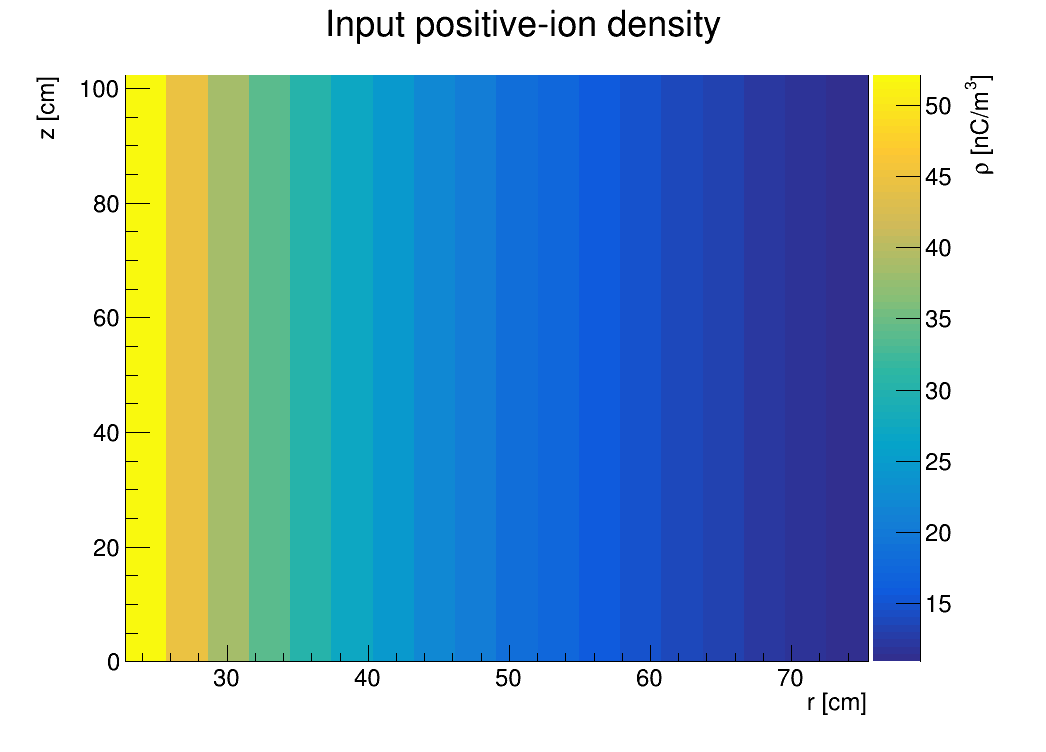

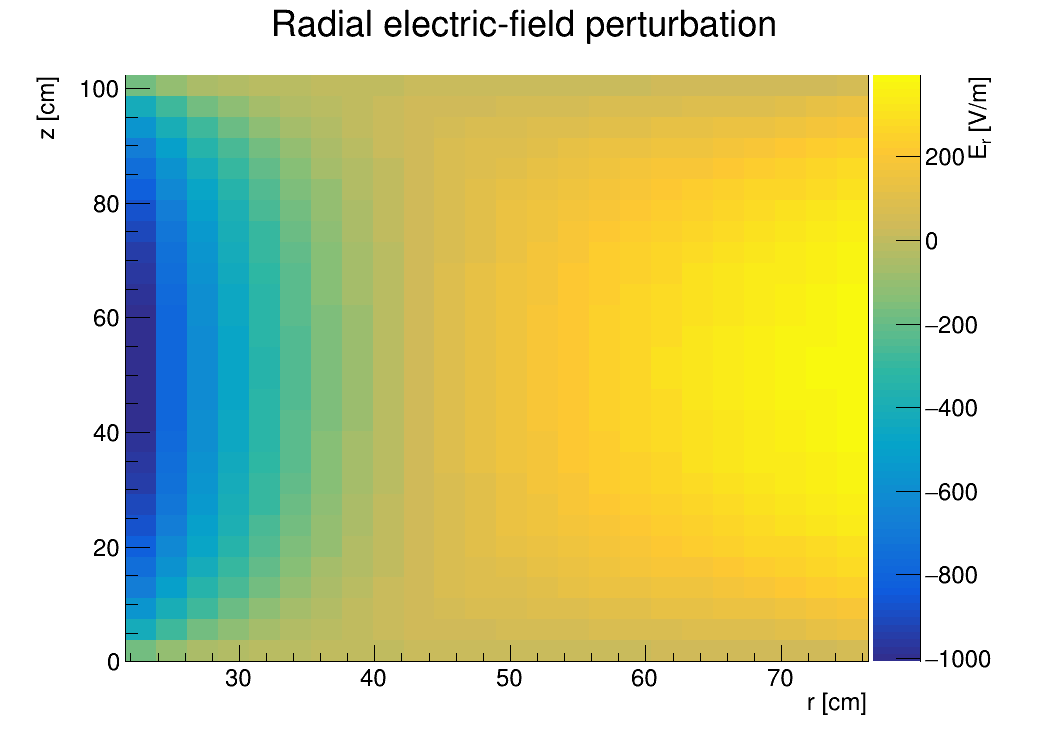

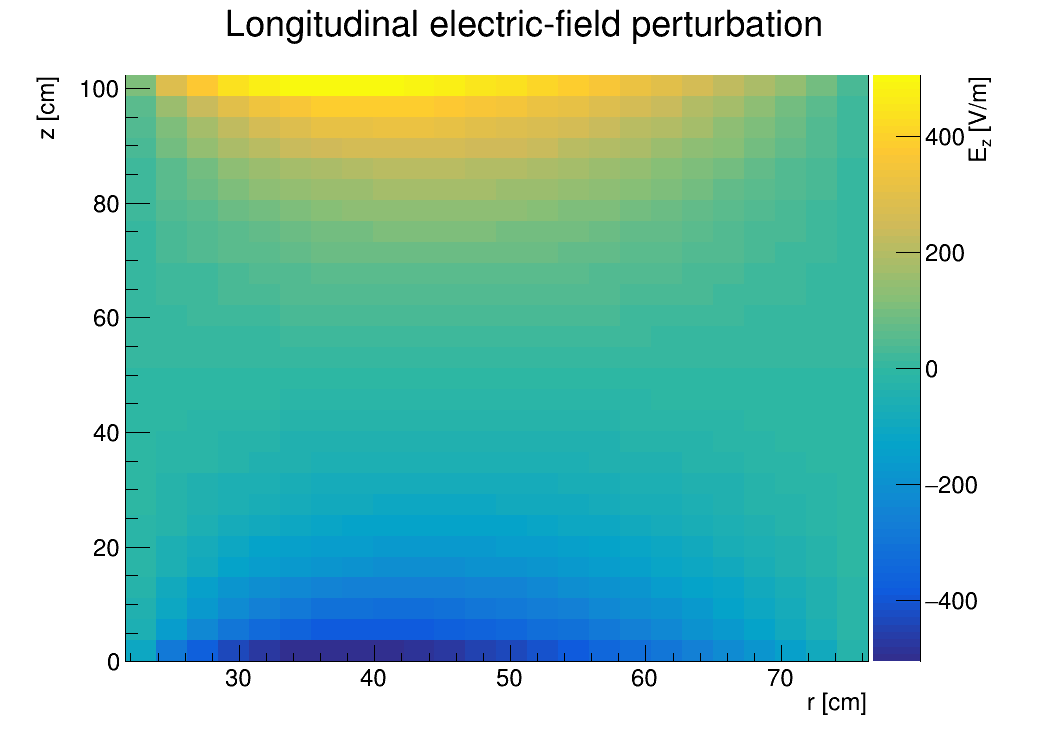

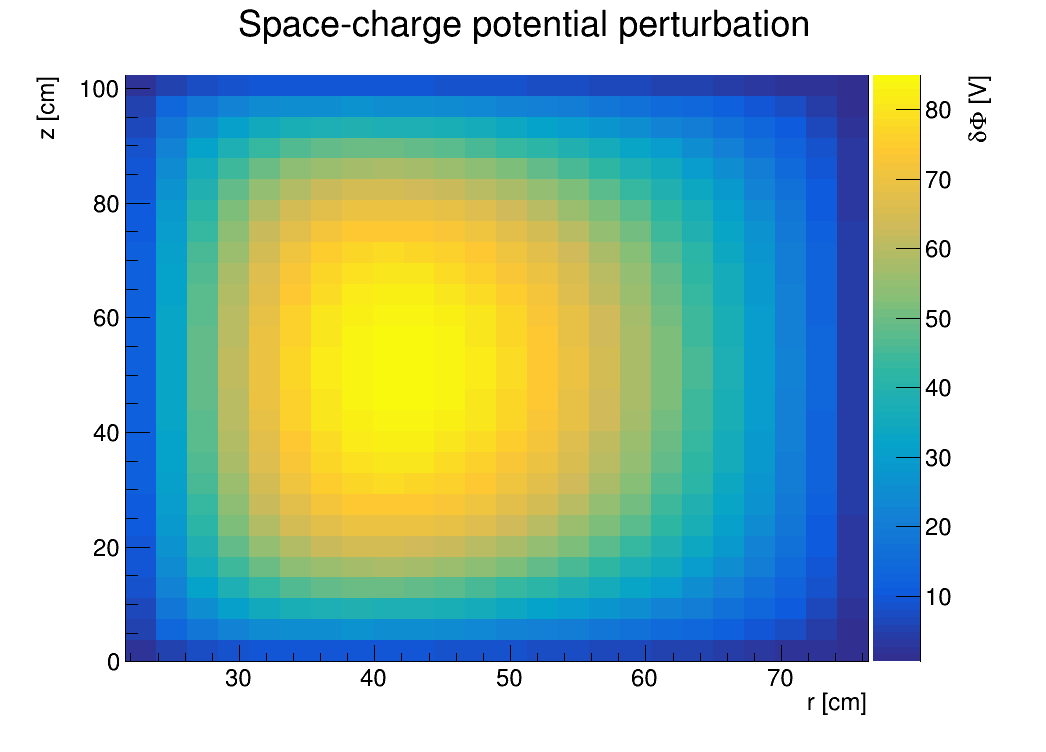

Info in <TCanvas::Print>: png file rossegger_qa/qa_rho_rz.png has been created
Info in <TCanvas::Print>: png file rossegger_qa/qa_Er_rz.png has been created
Info in <TCanvas::Print>: png file rossegger_qa/qa_Ez_rz.png has been created
Info in <TCanvas::Print>: png file rossegger_qa/qa_Phi_rz.png has been created


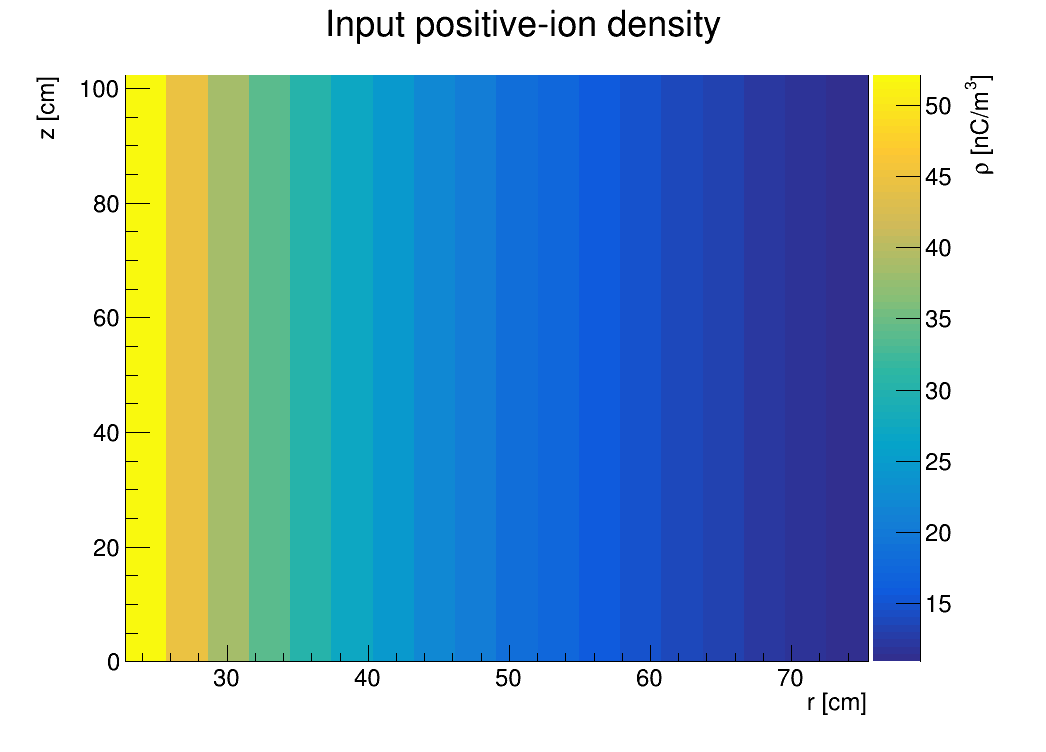

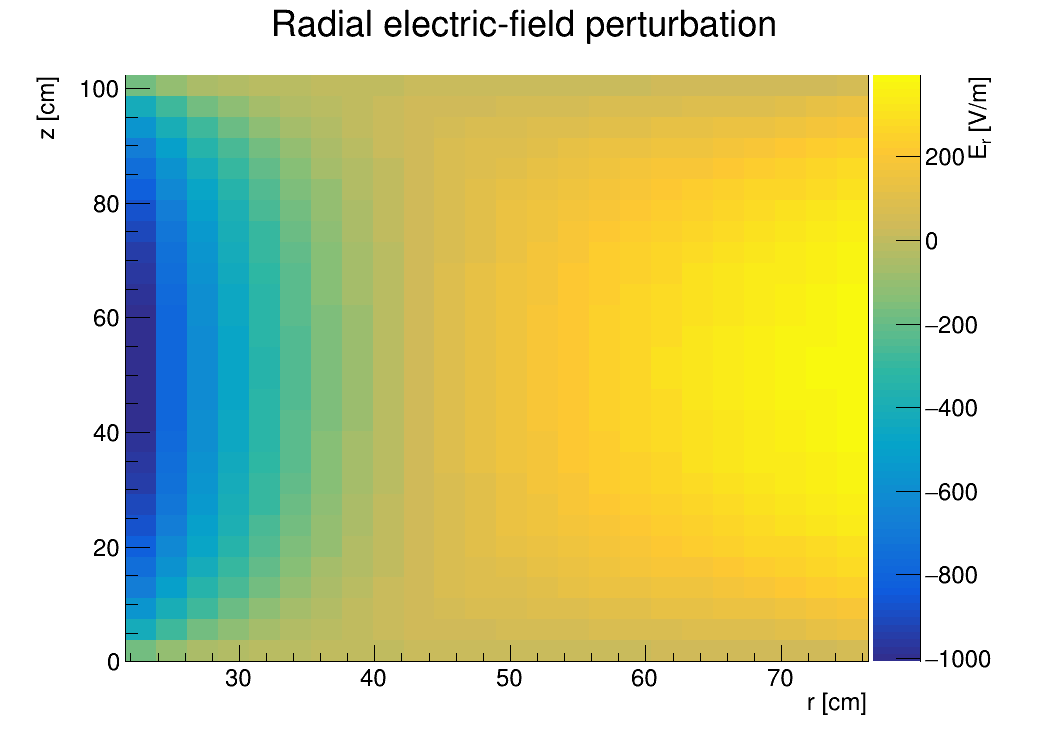

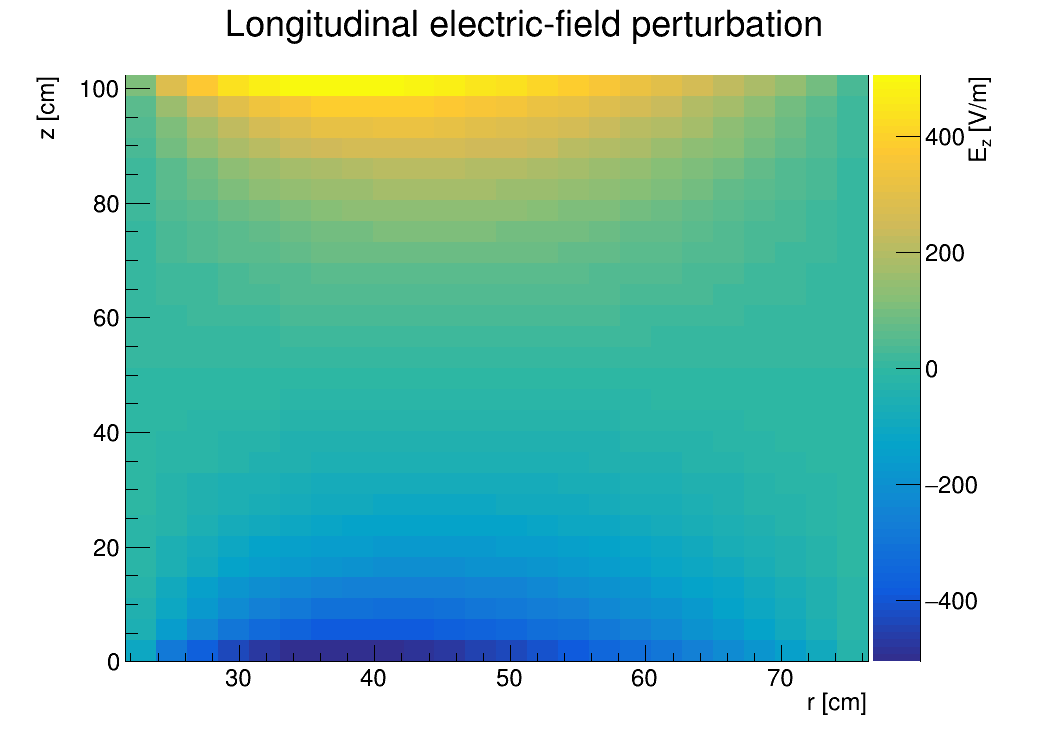

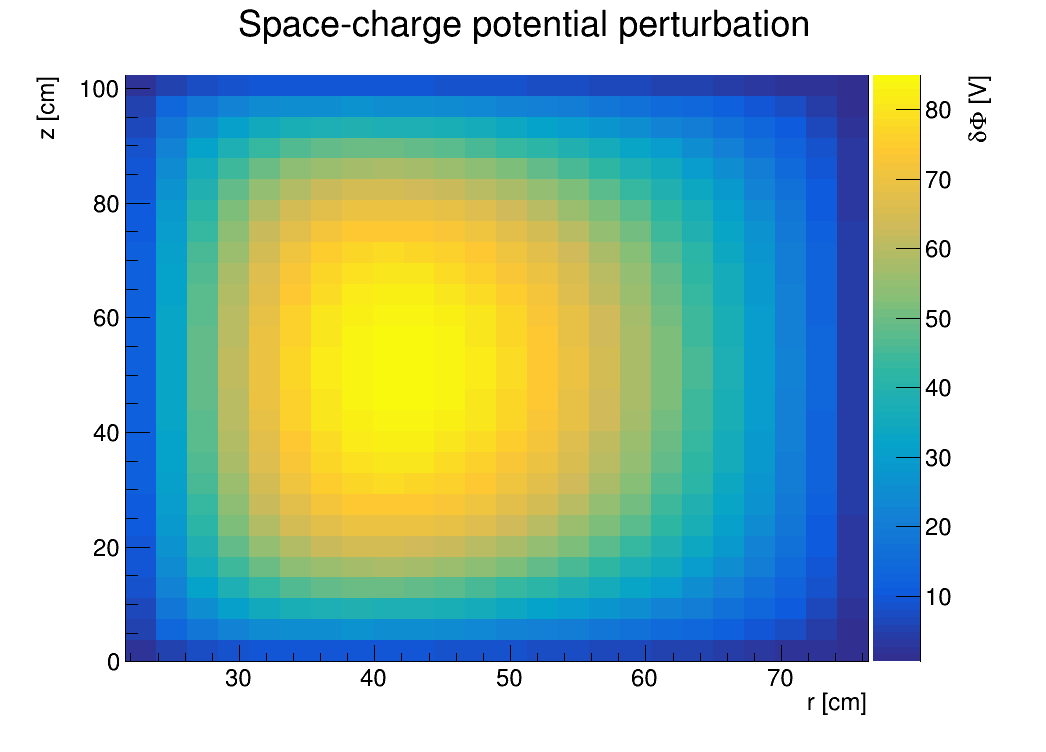

In [10]:
# ============================================================
# Visible r-z QA; no phi-specific plots by default
# ============================================================

if DO_QA:
    rho_rz = np.mean(rho, axis=1)
    Er_rz = np.mean(E_r, axis=1)
    Ez_rz = np.mean(E_z, axis=1)
    Phi_rz = np.mean(Phi, axis=1)

    draw_th2(
        "qa_rho_rz",
        make_th2(
            "hQARhoRZ",
            "Input positive-ion density",
            rho_rz*1e9,
            r_src_edges*M_TO_CM,
            z_src_edges*M_TO_CM,
            "r [cm]", "z [cm]", "#rho [nC/m^{3}]"
        )
    )

    draw_th2(
        "qa_Er_rz",
        make_th2(
            "hQAErRZ",
            "Radial electric-field perturbation",
            Er_rz,
            r_obs_edges*M_TO_CM,
            z_obs_edges*M_TO_CM,
            "r [cm]", "z [cm]", "E_{r} [V/m]"
        )
    )

    draw_th2(
        "qa_Ez_rz",
        make_th2(
            "hQAEzRZ",
            "Longitudinal electric-field perturbation",
            Ez_rz,
            r_obs_edges*M_TO_CM,
            z_obs_edges*M_TO_CM,
            "r [cm]", "z [cm]", "E_{z} [V/m]"
        )
    )

    draw_th2(
        "qa_Phi_rz",
        make_th2(
            "hQAPhiRZ",
            "Space-charge potential perturbation",
            Phi_rz,
            r_obs_edges*M_TO_CM,
            z_obs_edges*M_TO_CM,
            "r [cm]", "z [cm]", "#delta#Phi [V]"
        )
    )

if DO_QA and DO_PHI_QA:
    iz = NZ_OBS//2
    draw_th2(
        "qa_Ephi_rphi",
        make_th2(
            "hQAEphiRPhi",
            f"E_{{#phi}} at z={z_obs[iz]*M_TO_CM:.1f} cm",
            E_phi[:, :, iz],
            r_obs_edges*M_TO_CM,
            phi_obs_edges,
            "r [cm]", "#phi [rad]", "E_{#phi} [V/m]"
        )
    )

## 9. Rossegger component-specific Green-function kernels

The full three-dimensional production field above is calculated from one common scalar eigenfunction Green function. Rossegger also gives alternative but mathematically equivalent representations that are especially useful after differentiating the potential.

This section draws the two component-specific kernels used in the separate optimized axisymmetric solver:

- the hyperbolic longitudinal kernel used for $E_z$;
- the modified-Bessel radial kernel used for $E_r$.

These plots are useful for comparing the implementation directly with public Rossegger figures.

### Meaning of the source and observation coordinates

The dashed vertical line marks the fixed source coordinate:

- $z'$ for the longitudinal kernel;
- $r'$ for the radial kernel.

The horizontal coordinate is the observation position. Therefore, the visible branch change at the dashed line is expected: the Green function has different analytical expressions on the two sides of the source.

### Longitudinal kernel for $E_z$

For radial eigenvalue $k_n$,

$$
G_{k_n}(z,z')
=
\frac{
\sinh(k_n z_<)\,
\sinh[k_n(L-z_>)]
}{
k_n\sinh(k_nL)
},
$$

where

$$
z_< = \min(z,z'),
\qquad
z_> = \max(z,z').
$$

The longitudinal field uses

$$
\frac{\partial G_{k_n}(z,z')}{\partial z}.
$$

This derivative changes branch at $z=z'$. The jump is the expected point-source behavior. The production calculation integrates over finite source voxels, so the final physical field is smoother.

### Radial kernel for $E_r$

For longitudinal mode

$$
q_l=\frac{l\pi}{L},
$$

define

$$
u_l(r)
=
I_0(q_lr)K_0(q_la)
-
K_0(q_lr)I_0(q_la),
$$

$$
v_l(r)
=
I_0(q_lr)K_0(q_lb)
-
K_0(q_lr)I_0(q_lb).
$$

The radial Green function is

$$
g_l(r,r')
=
-\frac{
u_l(r_<)\,v_l(r_>)
}{
C_l
},
$$

with

$$
C_l
=
K_0(q_la)I_0(q_lb)
-
I_0(q_la)K_0(q_lb).
$$

The function itself is continuous at $r=r'$, while its derivative changes branch. The function vanishes at the physical field-cage radii $r=a$ and $r=b$.

In [11]:
# ============================================================
# Component-specific Rossegger kernel helpers
# ============================================================

def d_green_z_dz(k, z_obs_value, z_source_value):
    """Derivative with respect to observation z."""
    if z_obs_value < z_source_value:
        return (
            np.cosh(k*z_obs_value)
            * np.sinh(k*(L-z_source_value))
            / np.sinh(k*L)
        )
    if z_obs_value > z_source_value:
        return (
            -np.sinh(k*z_source_value)
            * np.cosh(k*(L-z_obs_value))
            / np.sinh(k*L)
        )
    return 0.0


def radial_modified_bessel_parts(q):
    """Return u, du/dr, v, dv/dr, and C for the m=0 radial kernel."""
    I0a = special.iv(0, q*a)
    K0a = special.kv(0, q*a)
    I0b = special.iv(0, q*b)
    K0b = special.kv(0, q*b)

    C = K0a*I0b - I0a*K0b

    def u(r):
        return (
            special.iv(0, q*r)*K0a
            - special.kv(0, q*r)*I0a
        )

    def du(r):
        return q*(
            special.iv(1, q*r)*K0a
            + special.kv(1, q*r)*I0a
        )

    def v(r):
        return (
            special.iv(0, q*r)*K0b
            - special.kv(0, q*r)*I0b
        )

    def dv(r):
        return q*(
            special.iv(1, q*r)*K0b
            + special.kv(1, q*r)*I0b
        )

    return u, du, v, dv, C


def graph_from_xy(x, y, name):
    x = np.asarray(x, dtype="d")
    y = np.asarray(y, dtype="d")
    g = root.TGraph(len(x), x, y)
    g.SetName(name)
    g.SetLineWidth(2)
    return g

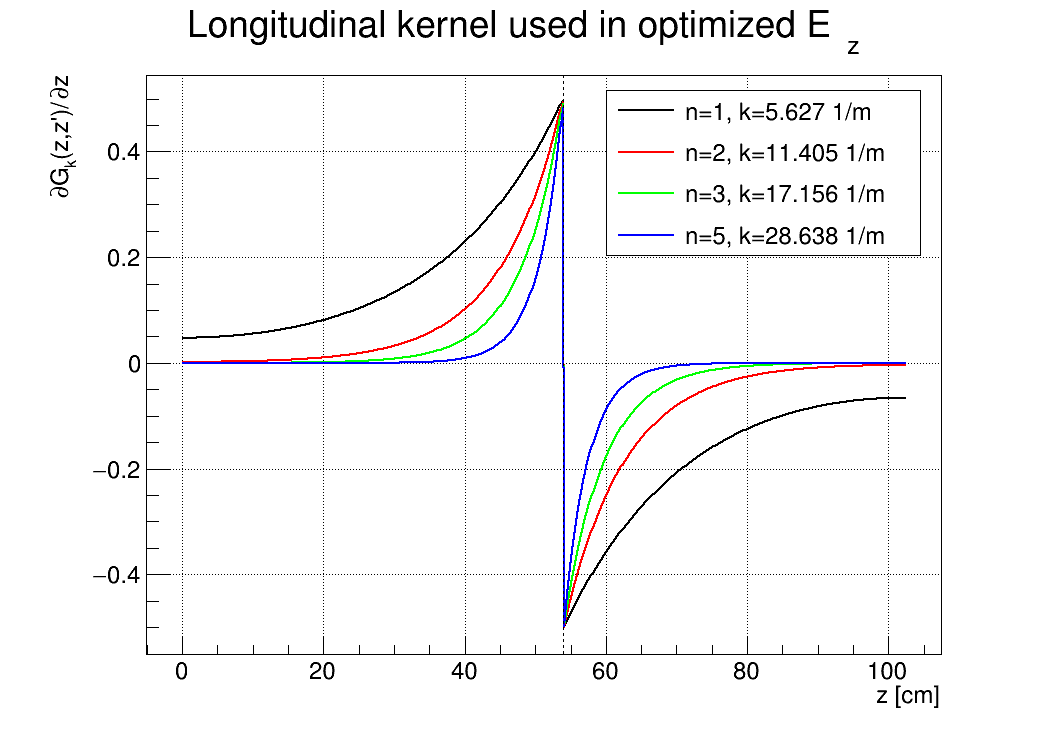

Info in <TCanvas::Print>: png file rossegger_qa/qa_rossegger_longitudinal_kernel.png has been created


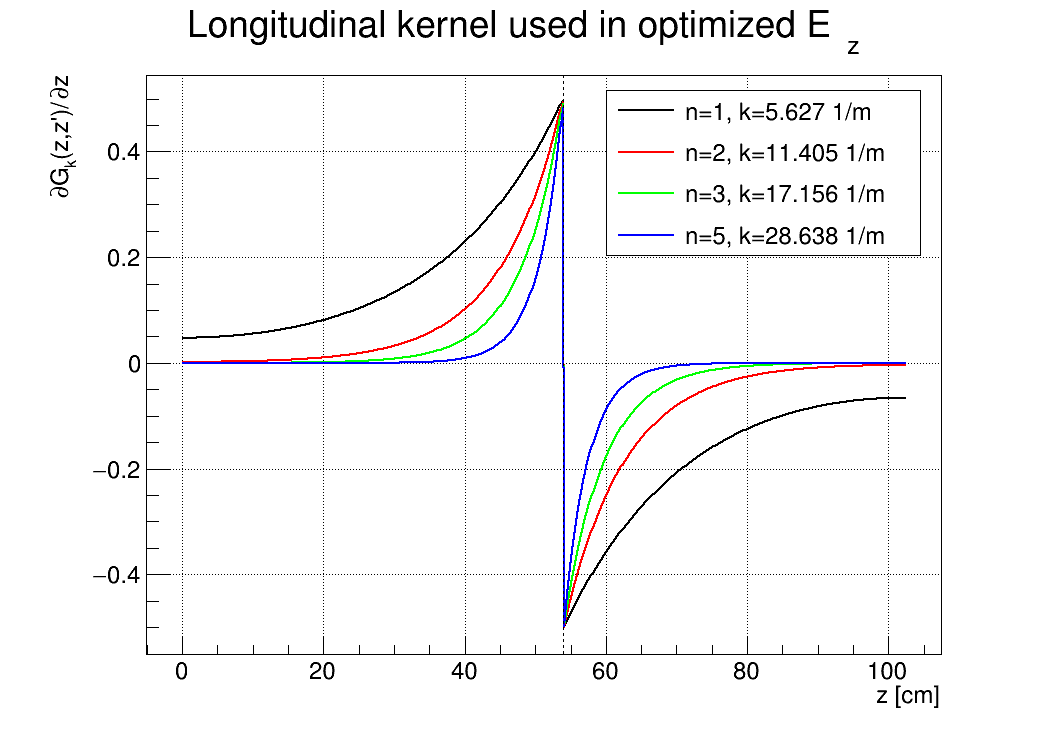

In [12]:
# ============================================================
# QA: longitudinal derivative used in optimized Ez
# ============================================================

if DO_QA:
    zprime_cm = 54.0
    zprime = zprime_cm*CM_TO_M
    z_plot = np.linspace(0.0, L, 700)

    k_indices = [0, 1, 2, 4]
    k_indices = [i for i in k_indices if i < len(k_modes[0])]

    c_gz = root.TCanvas("qa_rossegger_dGdz", "", 1050, 780)
    c_gz.SetGrid()
    c_gz.SetLeftMargin(0.14)
    c_gz.SetBottomMargin(0.13)

    mg_gz = root.TMultiGraph()
    leg_gz = root.TLegend(0.58, 0.66, 0.88, 0.88)
    local_graphs = []

    for color, idx in enumerate(k_indices, start=1):
        kval = k_modes[0][idx]
        values = np.array([
            d_green_z_dz(kval, zv, zprime)
            for zv in z_plot
        ])

        g = graph_from_xy(
            z_plot*M_TO_CM,
            values,
            f"gLongitudinalKernel_{idx}"
        )
        g.SetLineColor(color)
        g.SetMarkerColor(color)
        mg_gz.Add(g, "L")
        leg_gz.AddEntry(
            g,
            f"n={idx+1}, k={kval:.3f} 1/m",
            "l"
        )
        local_graphs.append(g)
        qa_objects.append(g)

    mg_gz.SetTitle(
        "Longitudinal kernel used in optimized E_{z};"
        "z [cm];"
        "#partialG_{k}(z,z')/#partialz"
    )
    mg_gz.Draw("A")
    leg_gz.Draw()

    c_gz.Update()
    ymin = root.gPad.GetUymin()
    ymax = root.gPad.GetUymax()

    source_line_z = root.TLine(
        zprime_cm, ymin,
        zprime_cm, ymax
    )
    source_line_z.SetLineStyle(2)
    source_line_z.Draw()
    qa_objects.append(source_line_z)

    c_gz.Modified()
    c_gz.Update()

    path = QA_DIRECTORY/"qa_rossegger_longitudinal_kernel.png"
    c_gz.SaveAs(str(path))
    display(Image(filename=str(path)))
    qa_canvases.append(c_gz)

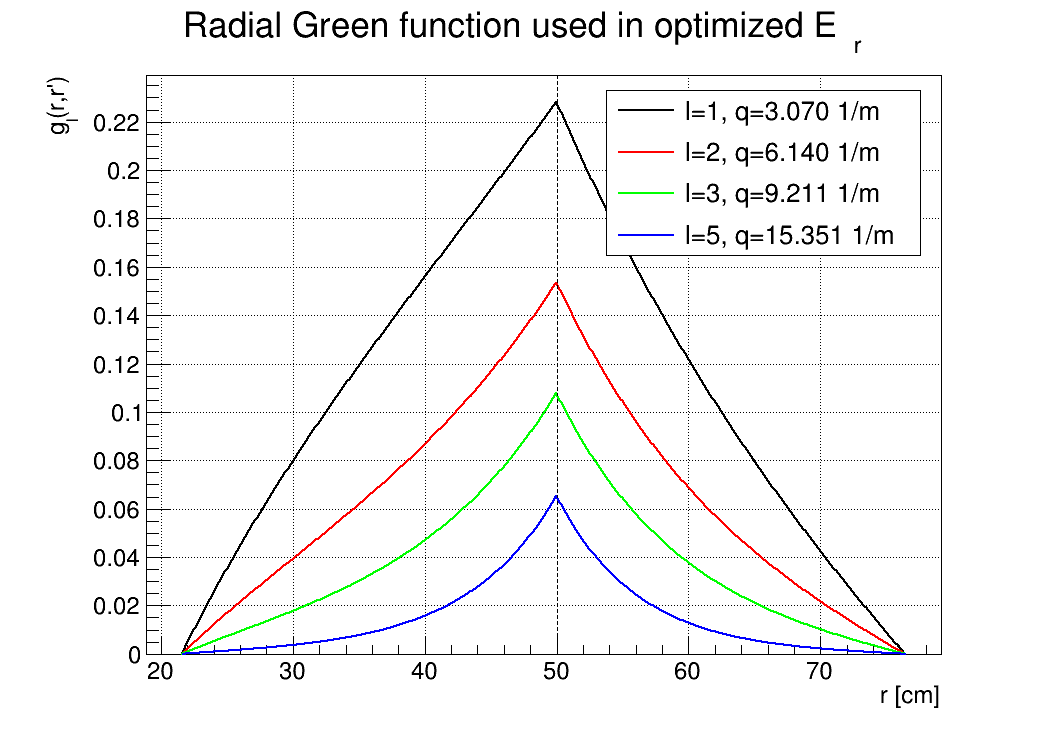

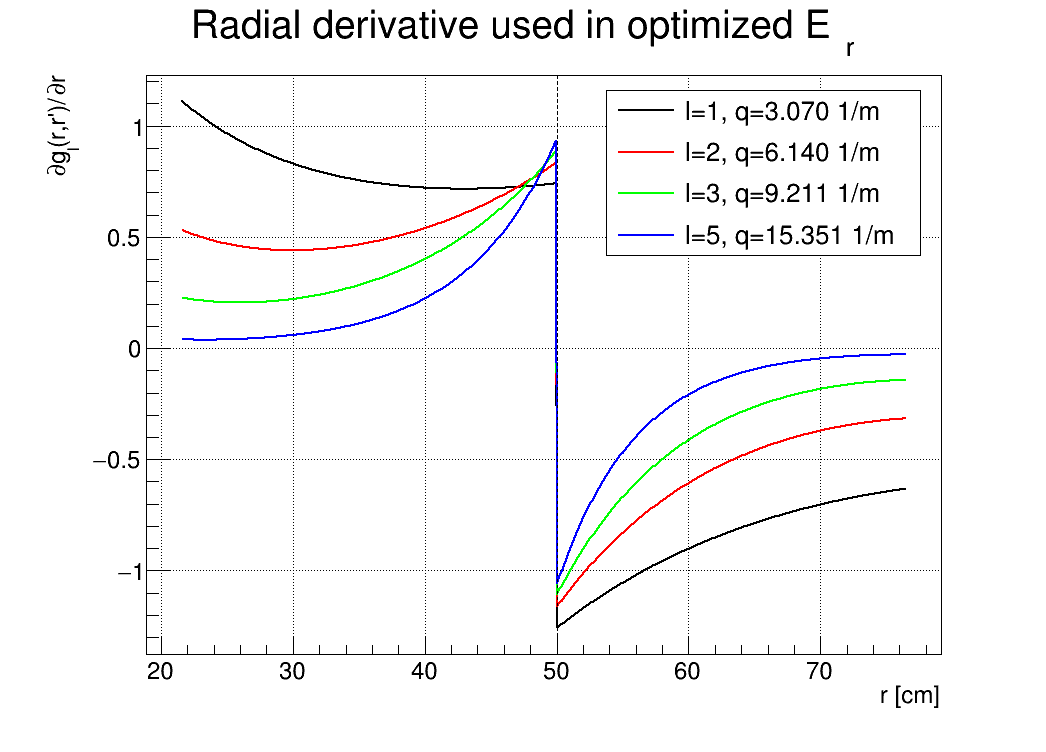

Info in <TCanvas::Print>: png file rossegger_qa/qa_rossegger_radial_green.png has been created
Info in <TCanvas::Print>: png file rossegger_qa/qa_rossegger_radial_derivative.png has been created


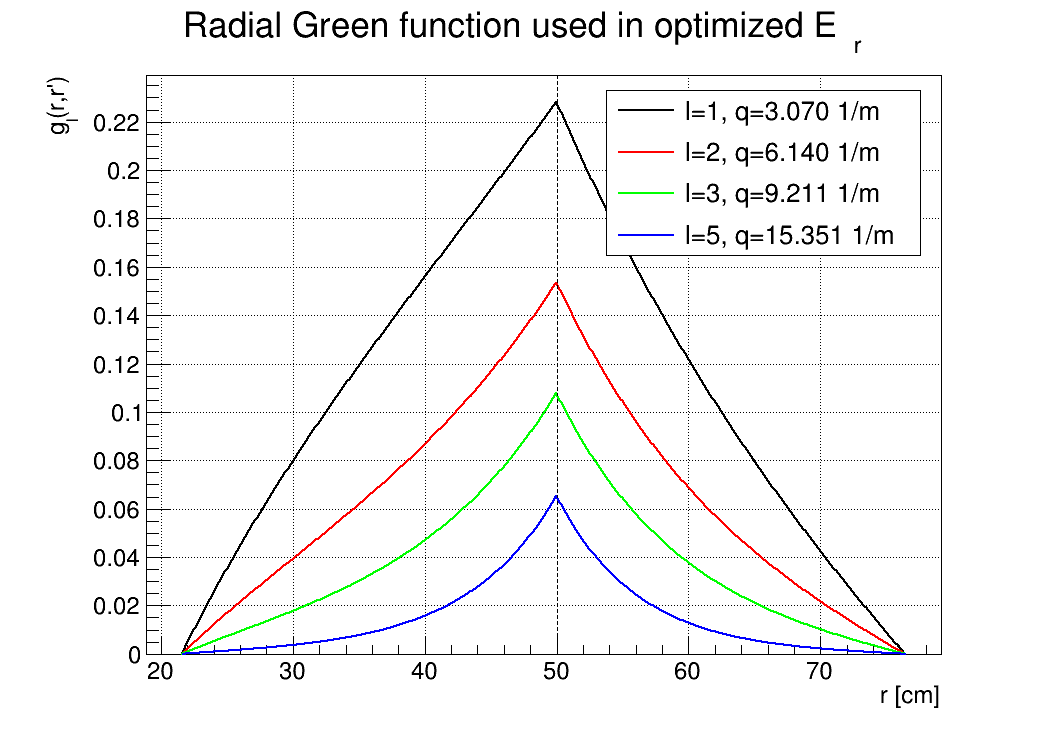

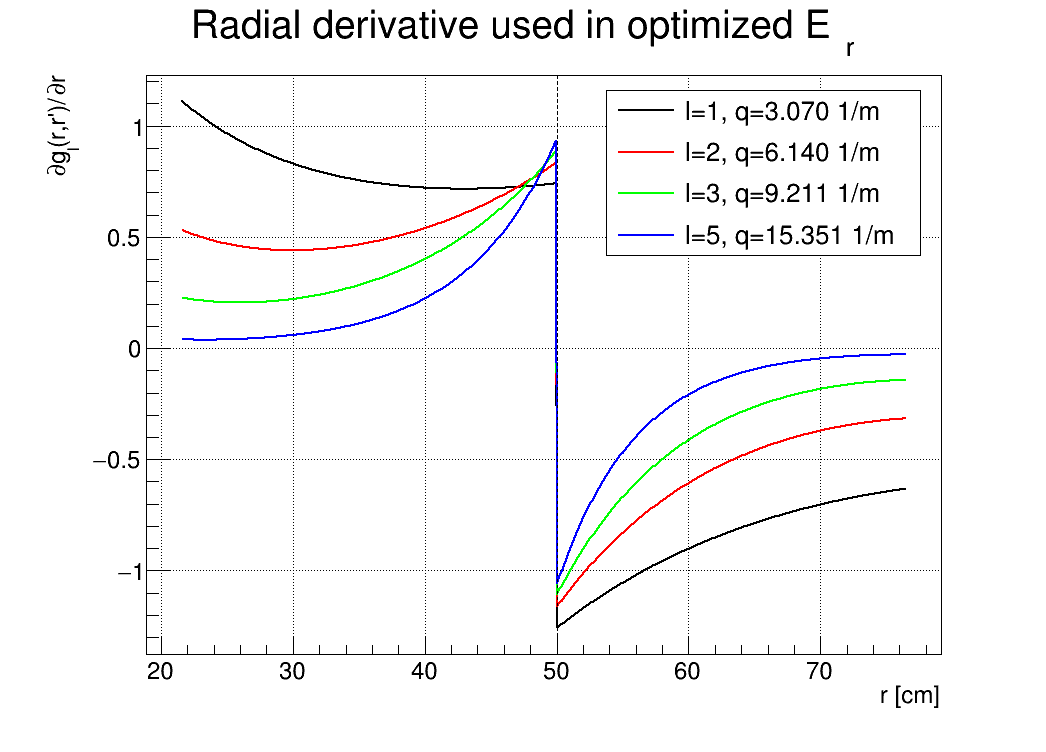

In [13]:
# ============================================================
# QA: radial Green function and derivative used in optimized Er
# ============================================================

if DO_QA:
    rprime_cm = 50.0
    rprime = rprime_cm*CM_TO_M
    r_plot = np.linspace(a, b, 700)

    l_indices = [0, 1, 2, 4]
    l_indices = [i for i in l_indices if i < len(q_modes)]

    # --- g_l(r,r')
    c_gr = root.TCanvas("qa_rossegger_radial_green", "", 1050, 780)
    c_gr.SetGrid()
    c_gr.SetLeftMargin(0.14)
    c_gr.SetBottomMargin(0.13)

    mg_gr = root.TMultiGraph()
    leg_gr = root.TLegend(0.58, 0.66, 0.88, 0.88)

    for color, idx in enumerate(l_indices, start=1):
        qval = q_modes[idx]
        u, du, v, dv, C = radial_modified_bessel_parts(qval)

        values = np.empty_like(r_plot)
        left = r_plot <= rprime
        right = ~left
        values[left] = -u(r_plot[left])*v(rprime)/C
        values[right] = -u(rprime)*v(r_plot[right])/C

        g = graph_from_xy(
            r_plot*M_TO_CM,
            values,
            f"gRadialGreen_{idx}"
        )
        g.SetLineColor(color)
        g.SetMarkerColor(color)
        mg_gr.Add(g, "L")
        leg_gr.AddEntry(
            g,
            f"l={idx+1}, q={qval:.3f} 1/m",
            "l"
        )
        qa_objects.append(g)

    mg_gr.SetTitle(
        "Radial Green function used in optimized E_{r};"
        "r [cm];"
        "g_{l}(r,r')"
    )
    mg_gr.Draw("A")
    leg_gr.Draw()

    c_gr.Update()
    source_line_r1 = root.TLine(
        rprime_cm,
        root.gPad.GetUymin(),
        rprime_cm,
        root.gPad.GetUymax()
    )
    source_line_r1.SetLineStyle(2)
    source_line_r1.Draw()
    qa_objects.append(source_line_r1)

    c_gr.Modified()
    c_gr.Update()
    path = QA_DIRECTORY/"qa_rossegger_radial_green.png"
    c_gr.SaveAs(str(path))
    display(Image(filename=str(path)))
    qa_canvases.append(c_gr)

    # --- dg_l/dr
    c_dgr = root.TCanvas("qa_rossegger_radial_derivative", "", 1050, 780)
    c_dgr.SetGrid()
    c_dgr.SetLeftMargin(0.14)
    c_dgr.SetBottomMargin(0.13)

    mg_dgr = root.TMultiGraph()
    leg_dgr = root.TLegend(0.58, 0.66, 0.88, 0.88)

    for color, idx in enumerate(l_indices, start=1):
        qval = q_modes[idx]
        u, du, v, dv, C = radial_modified_bessel_parts(qval)

        values = np.empty_like(r_plot)
        left = r_plot < rprime
        right = ~left
        values[left] = -du(r_plot[left])*v(rprime)/C
        values[right] = -u(rprime)*dv(r_plot[right])/C

        g = graph_from_xy(
            r_plot*M_TO_CM,
            values,
            f"gRadialDerivative_{idx}"
        )
        g.SetLineColor(color)
        g.SetMarkerColor(color)
        mg_dgr.Add(g, "L")
        leg_dgr.AddEntry(
            g,
            f"l={idx+1}, q={qval:.3f} 1/m",
            "l"
        )
        qa_objects.append(g)

    mg_dgr.SetTitle(
        "Radial derivative used in optimized E_{r};"
        "r [cm];"
        "#partialg_{l}(r,r')/#partialr"
    )
    mg_dgr.Draw("A")
    leg_dgr.Draw()

    c_dgr.Update()
    source_line_r2 = root.TLine(
        rprime_cm,
        root.gPad.GetUymin(),
        rprime_cm,
        root.gPad.GetUymax()
    )
    source_line_r2.SetLineStyle(2)
    source_line_r2.Draw()
    qa_objects.append(source_line_r2)

    c_dgr.Modified()
    c_dgr.Update()
    path = QA_DIRECTORY/"qa_rossegger_radial_derivative.png"
    c_dgr.SaveAs(str(path))
    display(Image(filename=str(path)))
    qa_canvases.append(c_dgr)

### Approximate point-source field kernels in the $r$-$z$ plane

The next maps combine several modes for one source point,

$$
r'=50\ \mathrm{cm},
\qquad
z'=54\ \mathrm{cm}.
$$

They show the expected directional structure of the field kernel before convolution with the extended ion density.

The plotted normalization is arbitrary because an ideal mathematical point source is singular. The physically used field is finite because the production source is integrated over finite voxels.

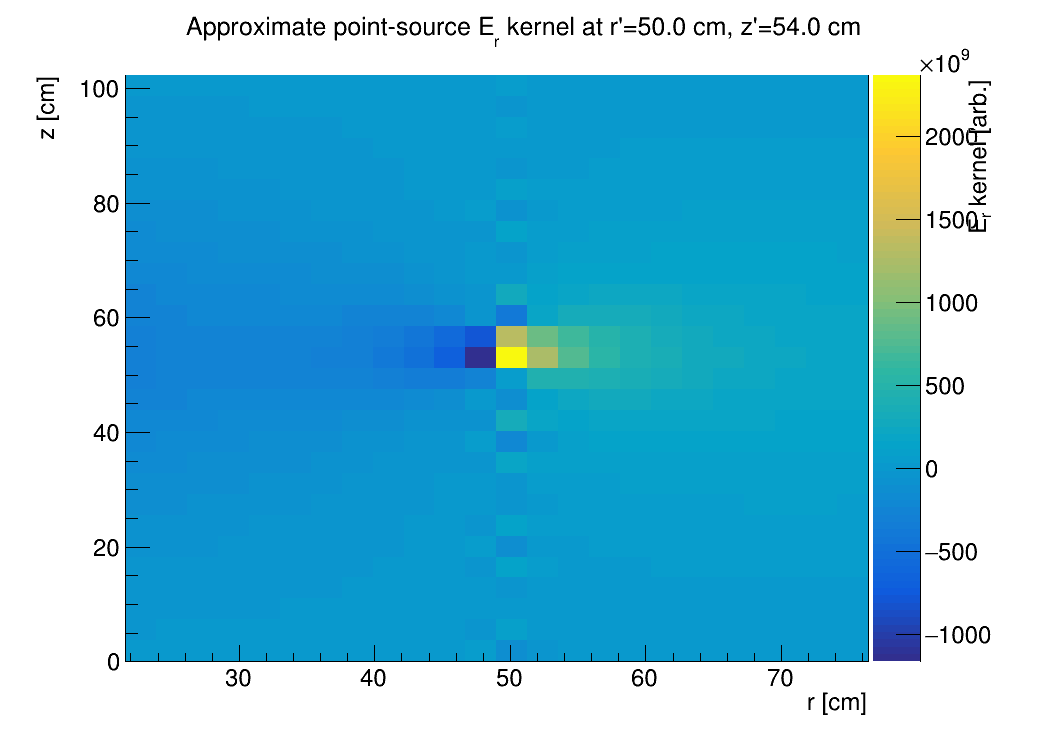

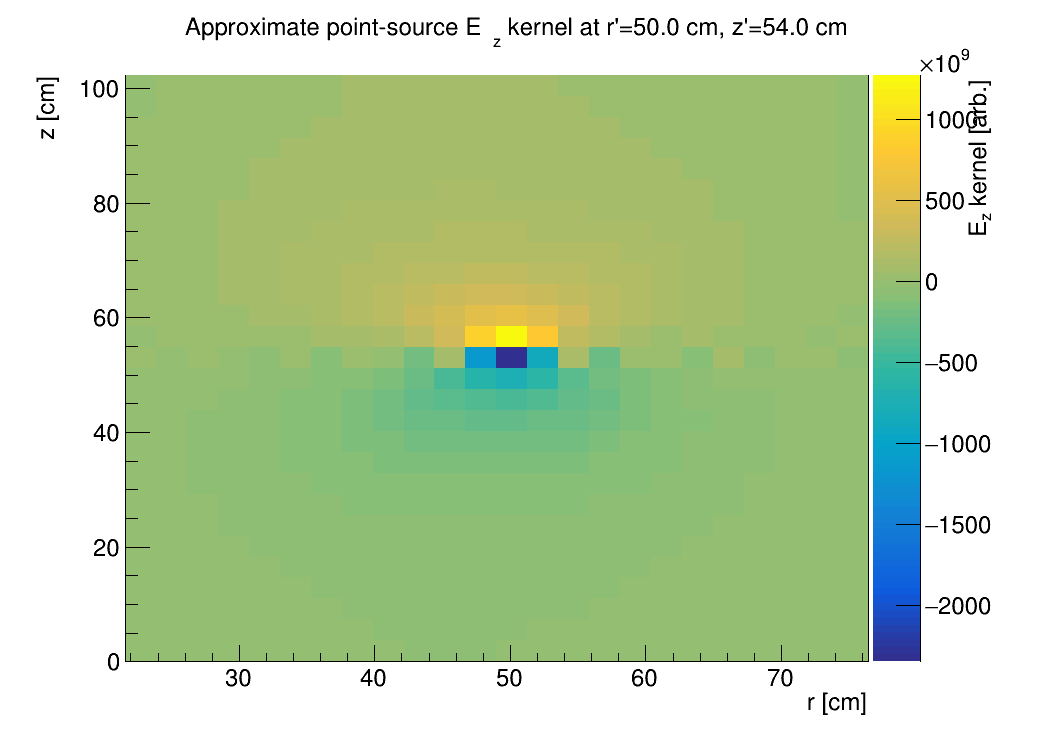

Info in <TCanvas::Print>: png file rossegger_qa/qa_Er_point_kernel.png has been created
Info in <TCanvas::Print>: png file rossegger_qa/qa_Ez_point_kernel.png has been created


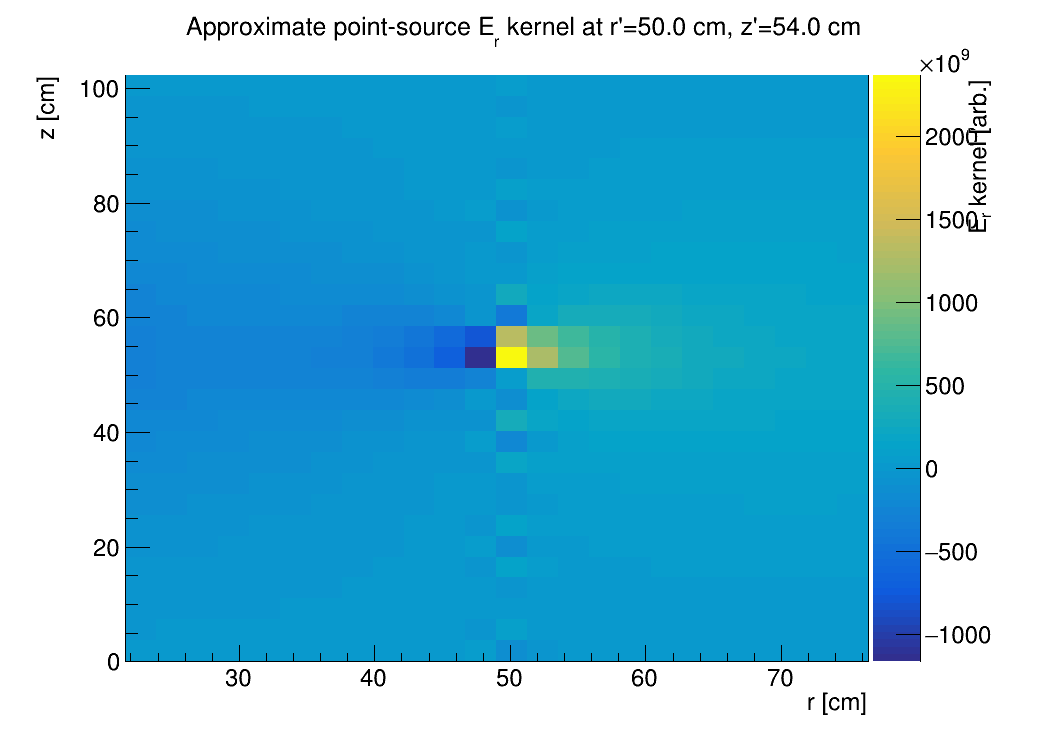

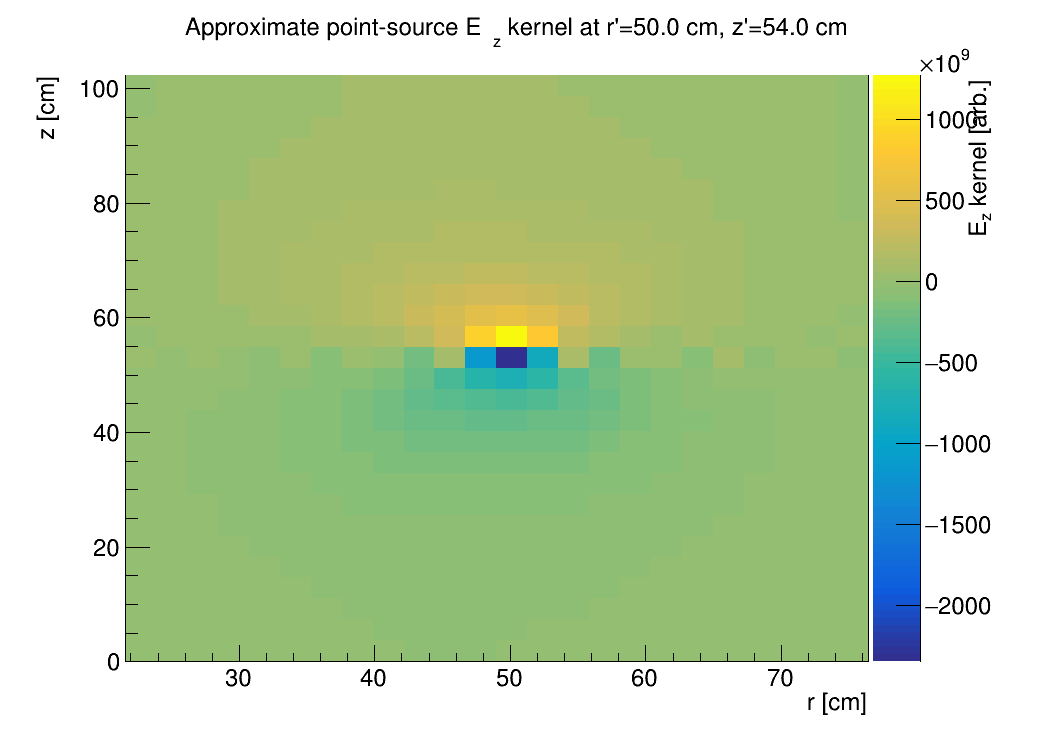

In [14]:
# ============================================================
# QA: approximate point-source Er and Ez kernels in r-z
# ============================================================

if DO_QA:
    r0_cm = 50.0
    z0_cm = 54.0
    r0 = r0_cm*CM_TO_M
    z0 = z0_cm*CM_TO_M

    Er_kernel = np.zeros((NR_OBS, NZ_OBS), dtype=np.float64)
    Ez_kernel = np.zeros((NR_OBS, NZ_OBS), dtype=np.float64)

    # Ez: ordinary-Bessel radial modes + hyperbolic longitudinal derivative
    for n, kval in enumerate(k_modes[0][:N_RADIAL_MODES]):
        R_source = radial_basis(kval, 0, r0)
        R_observation = radial_basis(kval, 0, r_obs)
        norm = radial_norms[0][n]

        dG = np.array([
            d_green_z_dz(kval, zv, z0)
            for zv in z_obs
        ])

        Ez_kernel += (
            -1.0/EPSILON_0
            * np.outer(
                R_observation*R_source/norm,
                dG
            )
        )

    # Er: longitudinal sine modes + modified-Bessel radial derivative
    for qval in q_modes[:N_LONGITUDINAL_MODES]:
        u, du, v, dv, C = radial_modified_bessel_parts(qval)

        dgdr = np.empty_like(r_obs)
        left = r_obs < r0
        right = ~left
        dgdr[left] = -du(r_obs[left])*v(r0)/C
        dgdr[right] = -u(r0)*dv(r_obs[right])/C

        zfactor = np.sin(qval*z_obs)*np.sin(qval*z0)

        Er_kernel += (
            -2.0/(EPSILON_0*L)
            * np.outer(dgdr, zfactor)
        )

    draw_th2(
        "qa_Er_point_kernel",
        make_th2(
            "hErPointKernel",
            (
                "Approximate point-source E_{r} kernel "
                f"at r'={r0_cm:.1f} cm, z'={z0_cm:.1f} cm"
            ),
            Er_kernel,
            r_obs_edges*M_TO_CM,
            z_obs_edges*M_TO_CM,
            "r [cm]",
            "z [cm]",
            "E_{r} kernel [arb.]"
        )
    )

    draw_th2(
        "qa_Ez_point_kernel",
        make_th2(
            "hEzPointKernel",
            (
                "Approximate point-source E_{z} kernel "
                f"at r'={r0_cm:.1f} cm, z'={z0_cm:.1f} cm"
            ),
            Ez_kernel,
            r_obs_edges*M_TO_CM,
            z_obs_edges*M_TO_CM,
            "r [cm]",
            "z [cm]",
            "E_{z} kernel [arb.]"
        )
    )

In [15]:
# ============================================================
# Symmetry, boundary, and Green reciprocity QA
# ============================================================

if DO_QA:
    field_scale = max(
        np.max(np.abs(E_r)),
        np.max(np.abs(E_z)),
        1e-30
    )

    phi_spread = max(
        np.max(np.ptp(E_r, axis=1)),
        np.max(np.ptp(E_z, axis=1)),
        np.max(np.abs(E_phi))
    )/field_scale

    print("Relative phi variation =", phi_spread)

    if phi_is_uniform and phi_spread > 1e-9:
        raise RuntimeError(
            "Axisymmetric source produced significant phi dependence."
        )

    # For a z-uniform source:
    Er_even = np.max(
        np.abs(E_r - E_r[:, :, ::-1])
    )/max(np.max(np.abs(E_r)), 1e-30)

    Ez_odd = np.max(
        np.abs(E_z + E_z[:, :, ::-1])
    )/max(np.max(np.abs(E_z)), 1e-30)

    print("Er reflection-even residual =", Er_even)
    print("Ez reflection-odd residual  =", Ez_odd)

    # Reciprocity can only be checked directly on matching coordinates.
    nmatch_r = min(N_GREEN_R_OBS, N_GREEN_R_SRC)
    nmatch_p = min(N_GREEN_PHI_OBS, N_GREEN_PHI_SRC)
    nmatch_z = min(N_GREEN_Z_OBS, N_GREEN_Z_SRC)

    # Evaluate a few direct pairs with the same scalar function below.

Relative phi variation = 9.02643442887873e-16
Er reflection-even residual = 6.769825821659047e-16
Ez reflection-odd residual  = 1.3466566470743688e-15


In [16]:
# ============================================================
# Pointwise scalar Green function for QA and comparisons
# ============================================================

def green_point(r, phi, z, rp, phip, zp,
                m_max=None, n_radial=None, n_longitudinal=None):
    if m_max is None:
        m_max = M_PHI_EFFECTIVE_MAX
    if n_radial is None:
        n_radial = N_RADIAL_MODES
    if n_longitudinal is None:
        n_longitudinal = N_LONGITUDINAL_MODES

    value = 0.0

    for m in range(min(m_max, M_PHI_EFFECTIVE_MAX)+1):
        angular = (
            (2.0 if m > 0 else 1.0)/(2.0*np.pi)
            * np.cos(m*(phi-phip))
        )

        for n, k in enumerate(k_modes[m][:n_radial]):
            radial = (
                radial_basis(k, m, r)
                * radial_basis(k, m, rp)
                / radial_norms[m][n]
            )

            q = q_modes[:n_longitudinal]
            longitudinal = np.sum(
                (2.0/L)
                * np.sin(q*z)
                * np.sin(q*zp)
                / (k*k + q*q)
            )

            value += angular*radial*longitudinal

    return value

if DO_QA:
    test_pairs = [
        (0.35, 0.2, 0.25, 0.60, 1.1, 0.80),
        (0.50, 2.0, 0.40, 0.42, 4.0, 0.72),
        (0.70, 5.0, 0.90, 0.30, 0.4, 0.20),
    ]

    reciprocity_residuals = []
    for point in test_pairs:
        r, p, z, rp, pp, zp = point
        g12 = green_point(r, p, z, rp, pp, zp)
        g21 = green_point(rp, pp, zp, r, p, z)
        residual = abs(g12-g21)/max(abs(g12), abs(g21), 1e-30)
        reciprocity_residuals.append(residual)

    print("Max Green reciprocity residual =", max(reciprocity_residuals))

Max Green reciprocity residual = 3.1954500432674584e-14


## 11. Gauss-law QA

Poisson's equation implies

$$
\nabla\cdot\mathbf E
=
\frac{\rho}{\epsilon_0}.
$$

In cylindrical coordinates,

$$
\nabla\cdot\mathbf E
=
\frac{1}{r}\frac{\partial(rE_r)}{\partial r}
+
\frac{1}{r}\frac{\partial E_\phi}{\partial\phi}
+
\frac{\partial E_z}{\partial z}.
$$

The field grid is differentiated numerically and compared with the input density interpolated onto the observation grid.

This is a demanding test because it differentiates an already truncated modal sum. The largest local residuals are expected near sharp source edges and near boundaries. The volume-integrated and bulk residuals are more informative than a single worst bin.

Gauss-law bulk RMS / peak rho = 0.01632198566558499
Gauss-law bulk max / peak rho = 0.054724187809436005


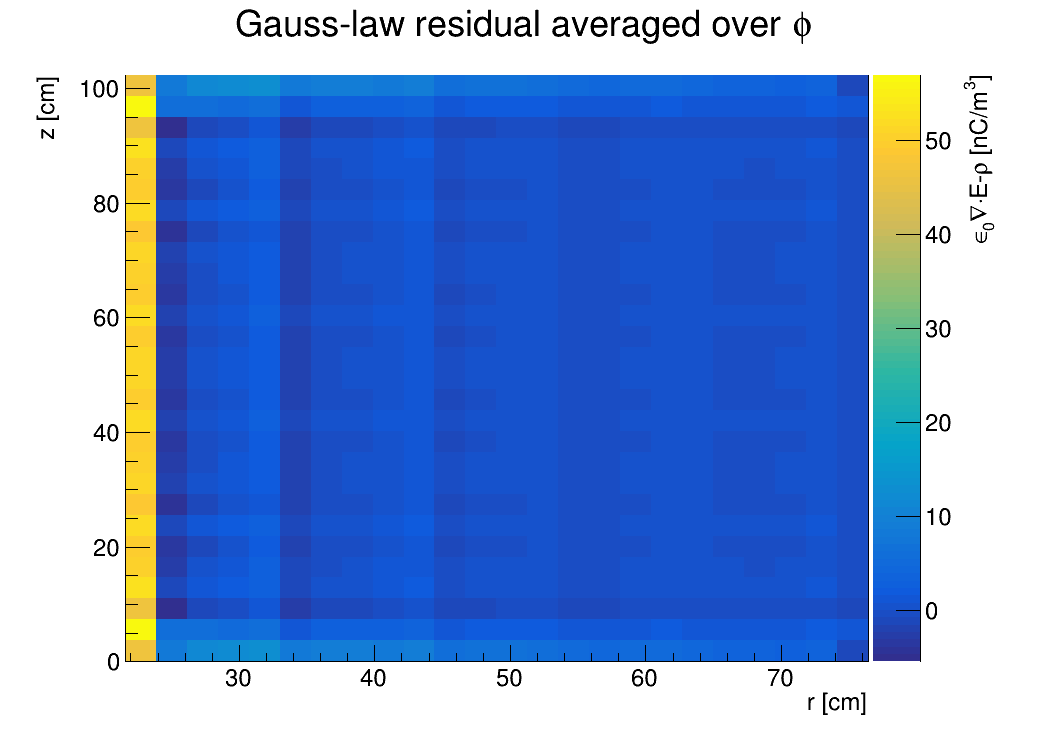

Info in <TCanvas::Print>: png file rossegger_qa/qa_gauss_residual_rz.png has been created


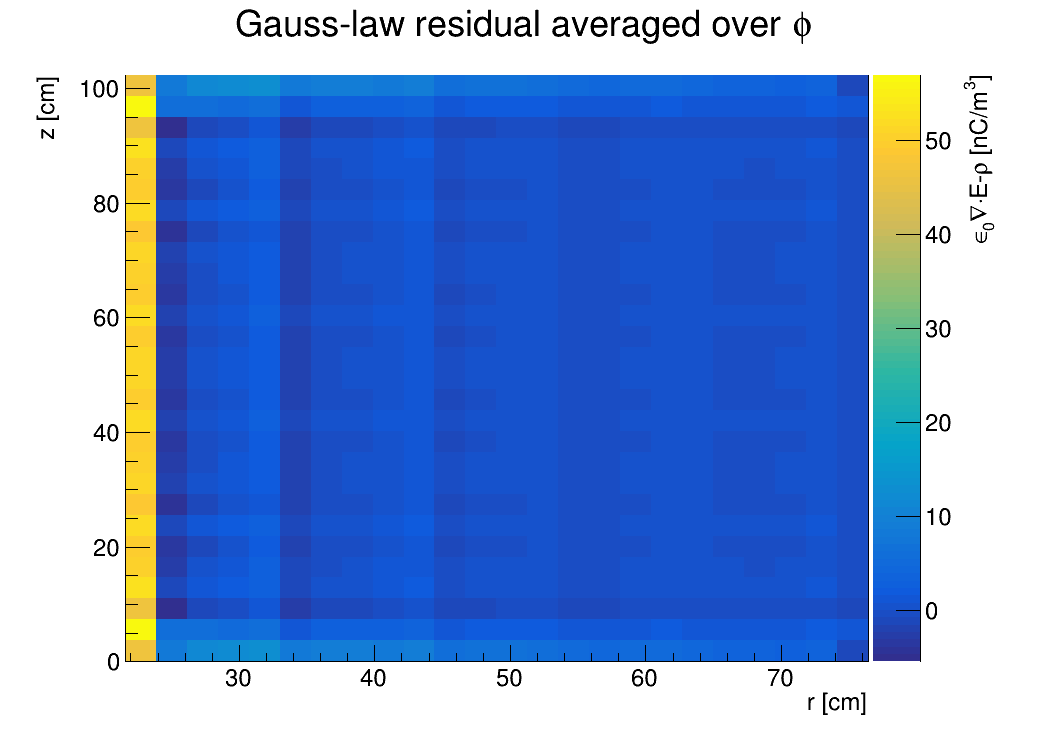

In [17]:
# ============================================================
# Three-dimensional Gauss-law QA
# ============================================================

if DO_QA and DO_GAUSS_QA:
    r3 = r_obs[:, None, None]

    d_rEr_dr = np.gradient(
        r3*E_r,
        r_obs,
        axis=0,
        edge_order=2
    )
    term_r = d_rEr_dr/r3

    dEphi_dphi = np.gradient(
        E_phi,
        phi_obs,
        axis=1,
        edge_order=2
    )
    term_phi = dEphi_dphi/r3

    term_z = np.gradient(
        E_z,
        z_obs,
        axis=2,
        edge_order=2
    )

    divE = term_r + term_phi + term_z

    # Interpolate rho to observation centers with nearest source voxel
    rho_obs = np.zeros_like(divE)
    for ir, rv in enumerate(r_obs):
        if source_r_min <= rv <= source_r_max:
            jr = np.argmin(abs(r_src-rv))
            for ip, pv in enumerate(phi_obs):
                jp = np.argmin(
                    abs(np.angle(np.exp(1j*(phi_src-pv))))
                )
                for iz, zv in enumerate(z_obs):
                    jz = np.argmin(abs(z_src-zv))
                    rho_obs[ir, ip, iz] = rho[jr, jp, jz]

    gauss_residual = EPSILON_0*divE - rho_obs
    rho_scale = max(np.max(np.abs(rho_obs)), 1e-30)

    # Exclude two bins at every boundary and bins directly crossing source onset.
    mask = np.ones_like(divE, dtype=bool)
    mask[:2, :, :] = False
    mask[-2:, :, :] = False
    mask[:, :, :2] = False
    mask[:, :, -2:] = False
    source_edge_mask = (
        np.abs(r_obs-source_r_min)
        < 2*np.mean(np.diff(r_obs))
    )
    mask[source_edge_mask, :, :] = False

    rms_rel = np.sqrt(
        np.mean((gauss_residual[mask]/rho_scale)**2)
    )
    max_rel = np.max(np.abs(gauss_residual[mask]))/rho_scale

    print("Gauss-law bulk RMS / peak rho =", rms_rel)
    print("Gauss-law bulk max / peak rho =", max_rel)

    draw_th2(
        "qa_gauss_residual_rz",
        make_th2(
            "hQAGaussResidualRZ",
            "Gauss-law residual averaged over #phi",
            np.mean(gauss_residual, axis=1)*1e9,
            r_obs_edges*M_TO_CM,
            z_obs_edges*M_TO_CM,
            "r [cm]", "z [cm]",
            "#epsilon_{0}#nabla#upointE-#rho [nC/m^{3}]"
        )
    )

## 12. Convergence QA

A truncated eigenfunction expansion must be tested, not assumed.

The convergence scan evaluates representative field points using progressively larger subsets of the already calculated modes. A stable plateau indicates that the selected truncation is adequate for the requested spatial resolution.

Sharp voxel boundaries converge more slowly than smooth densities. Therefore, a residual concentrated at the $30\ \mathrm{cm}$ source turn-on does not imply that $30\ \mathrm{cm}$ was treated as a conducting boundary. It reflects the Fourier-Bessel representation of a discontinuous source.

In [18]:
# ============================================================
# Lightweight convergence QA by recomputing selected points
# ============================================================

def field_point_from_modes(r, phi, z, nrad, nlong, mmax):
    er = 0.0
    ep = 0.0
    ez = 0.0

    for m in range(min(mmax, M_PHI_EFFECTIVE_MAX)+1):
        angular_norm = 2.0*np.pi if m == 0 else np.pi
        cp = np.cos(m*phi)
        sp = np.sin(m*phi)

        for n, k in enumerate(k_modes[m][:nrad]):
            R = radial_basis(k, m, r)
            dR = radial_basis_derivative(k, m, r)
            norm = radial_norms[m][n]

            q = q_modes[:nlong]
            denom = (
                EPSILON_0*norm*(L/2.0)*angular_norm
                * (k*k + q*q)
            )
            Ac = modal_cos[m][n, :nlong]/denom
            As = modal_sin[m][n, :nlong]/denom

            sz = np.sin(q*z)
            qcz = q*np.cos(q*z)

            angular_amp = Ac*cp + As*sp
            er -= dR*np.sum(sz*angular_amp)
            ez -= R*np.sum(qcz*angular_amp)

            if m > 0:
                ep += (m/r)*R*np.sum(
                    sz*(Ac*sp-As*cp)
                )

    return er, ep, ez

if DO_QA and DO_CONVERGENCE_QA:
    probes = [
        (0.35, 0.0, 0.25),
        (0.52, 0.0, 0.52),
        (0.70, 0.0, 0.82),
    ]

    mode_steps = [4, 6, 8, 12, 16, min(N_RADIAL_MODES, N_LONGITUDINAL_MODES)]
    mode_steps = sorted(set(
        n for n in mode_steps
        if n <= N_RADIAL_MODES and n <= N_LONGITUDINAL_MODES
    ))

    for probe in probes:
        values = []
        for nm in mode_steps:
            values.append(
                field_point_from_modes(
                    *probe,
                    nrad=nm,
                    nlong=nm,
                    mmax=M_PHI_EFFECTIVE_MAX
                )
            )
        print("Convergence probe", probe)
        for nm, val in zip(mode_steps, values):
            print(f"  modes={nm:2d}: Er={val[0]: .6e}, Ephi={val[1]: .6e}, Ez={val[2]: .6e}")

Convergence probe (0.35, 0.0, 0.25)
  modes= 4: Er=-1.633113e+02, Ephi= 2.567197e-13, Ez=-1.225266e+02
  modes= 6: Er=-1.418397e+02, Ephi= 2.345694e-13, Ez=-8.230279e+01
  modes= 8: Er=-1.604472e+02, Ephi= 2.237530e-13, Ez=-1.008586e+02
  modes=12: Er=-1.601247e+02, Ephi= 2.311369e-13, Ez=-1.088531e+02
  modes=16: Er=-1.598801e+02, Ephi= 2.278601e-13, Ez=-1.041213e+02
  modes=18: Er=-1.611883e+02, Ephi= 2.284126e-13, Ez=-1.102694e+02
Convergence probe (0.52, 0.0, 0.52)
  modes= 4: Er= 1.661211e+02, Ephi= 1.620810e-13, Ez= 1.113415e-01
  modes= 6: Er= 1.946301e+02, Ephi= 1.753733e-13, Ez= 4.471460e+00
  modes= 8: Er= 1.793959e+02, Ephi= 1.704849e-13, Ez= 1.197561e+00
  modes=12: Er= 1.829334e+02, Ephi= 1.715903e-13, Ez= 1.589070e+00
  modes=16: Er= 1.841054e+02, Ephi= 1.717667e-13, Ez= 1.757293e+00
  modes=18: Er= 1.842563e+02, Ephi= 1.720493e-13, Ez= 3.452159e+00
Convergence probe (0.7, 0.0, 0.82)
  modes= 4: Er= 2.833371e+02, Ephi= 4.245414e-14, Ez= 5.678451e+01
  modes= 6: Er= 2.8269

## 13. ROOT output 1: sampled Green-function array

The first file contains:

- coordinate vectors for observation and source grids;
- the complete sampled six-dimensional array;
- modal truncation metadata;
- geometry metadata.

ROOT does not provide a standard six-dimensional histogram class. The array is therefore stored as a flat `TTree`, one row per observation-source pair, together with integer indices and physical coordinates.

The original six-dimensional shape is stored in metadata and can be reconstructed exactly.

In [19]:
# ============================================================
# Write sampled Green-function array
# ============================================================

from array import array

fg = root.TFile(GREEN_ROOT_FILE, "RECREATE")
if not fg or fg.IsZombie():
    raise OSError(f"Could not create {GREEN_ROOT_FILE}")

tree = root.TTree("GreenFunction", "Sampled Rossegger scalar Green function")

ir_o = array("i", [0]); ip_o = array("i", [0]); iz_o = array("i", [0])
ir_s = array("i", [0]); ip_s = array("i", [0]); iz_s = array("i", [0])
r_o = array("d", [0.]); p_o = array("d", [0.]); z_o = array("d", [0.])
r_s = array("d", [0.]); p_s = array("d", [0.]); z_s = array("d", [0.])
gval = array("d", [0.])

for name, arr, leaf in [
    ("ir_obs", ir_o, "ir_obs/I"), ("iphi_obs", ip_o, "iphi_obs/I"),
    ("iz_obs", iz_o, "iz_obs/I"), ("ir_src", ir_s, "ir_src/I"),
    ("iphi_src", ip_s, "iphi_src/I"), ("iz_src", iz_s, "iz_src/I"),
    ("r_obs_m", r_o, "r_obs_m/D"), ("phi_obs_rad", p_o, "phi_obs_rad/D"),
    ("z_obs_m", z_o, "z_obs_m/D"), ("r_src_m", r_s, "r_src_m/D"),
    ("phi_src_rad", p_s, "phi_src_rad/D"), ("z_src_m", z_s, "z_src_m/D"),
    ("G_m_inv", gval, "G_m_inv/D")
]:
    tree.Branch(name, arr, leaf)

for iro, rv in enumerate(green_r_obs):
    ir_o[0] = iro; r_o[0] = rv
    for ipo, pv in enumerate(green_phi_obs):
        ip_o[0] = ipo; p_o[0] = pv
        for izo, zv in enumerate(green_z_obs):
            iz_o[0] = izo; z_o[0] = zv
            for irs, rpv in enumerate(green_r_src):
                ir_s[0] = irs; r_s[0] = rpv
                for ips, ppv in enumerate(green_phi_src):
                    ip_s[0] = ips; p_s[0] = ppv
                    for izs, zpv in enumerate(green_z_src):
                        iz_s[0] = izs; z_s[0] = zpv
                        gval[0] = G_total[iro, ipo, izo, irs, ips, izs]
                        tree.Fill()

tree.Write()

green_metadata = {
    "description": "Sampled scalar Green function of grounded coaxial cavity",
    "shape": list(G_total.shape),
    "axis_order": [
        "r_obs", "phi_obs", "z_obs",
        "r_src", "phi_src", "z_src"
    ],
    "coordinate_units": {
        "r": "m", "phi": "rad", "z": "m"
    },
    "green_units": "1/m",
    "geometry_cm": {"a": A_CM, "b": B_CM, "L": L_CM},
    "m_max": M_PHI_EFFECTIVE_MAX,
    "n_radial": N_RADIAL_MODES,
    "n_longitudinal": N_LONGITUDINAL_MODES
}
root.TNamed("metadata_json", json.dumps(green_metadata, indent=2)).Write()
fg.Close()
print("Wrote", GREEN_ROOT_FILE)

Wrote sphenix_rossegger_green_function.root


## 14. ROOT output 2: full three-dimensional field maps

The second file contains:

- `hRho`: $\rho(r,\phi,z)$ in $\mathrm{C/m^3}$;
- `hPhi`: perturbing potential in volts;
- `hEr`: radial field in $\mathrm{V/m}$;
- `hEphi`: azimuthal field in $\mathrm{V/m}$;
- `hEz`: longitudinal field in $\mathrm{V/m}$;
- JSON metadata.

The histogram axes are:

$$
(r\,[\mathrm{cm}],\ \phi\,[\mathrm{rad}],\ z\,[\mathrm{cm}]).
$$

In [20]:
# ============================================================
# TH3 writing helper and full 3D output
# ============================================================

def make_th3(name, title, values, xedges, yedges, zedges,
             xtitle, ytitle, ztitle, value_title):
    h = root.TH3D(
        name, title,
        len(xedges)-1, np.asarray(xedges, dtype="d"),
        len(yedges)-1, np.asarray(yedges, dtype="d"),
        len(zedges)-1, np.asarray(zedges, dtype="d")
    )
    h.GetXaxis().SetTitle(xtitle)
    h.GetYaxis().SetTitle(ytitle)
    h.GetZaxis().SetTitle(ztitle)

    for ix in range(values.shape[0]):
        for iy in range(values.shape[1]):
            for iz in range(values.shape[2]):
                h.SetBinContent(ix+1, iy+1, iz+1, float(values[ix, iy, iz]))
    return h

ff = root.TFile(FIELD3D_ROOT_FILE, "RECREATE")
if not ff or ff.IsZombie():
    raise OSError(f"Could not create {FIELD3D_ROOT_FILE}")

hRho = make_th3(
    "hRho", "Positive-ion density",
    rho,
    r_src_edges*M_TO_CM, phi_src_edges, z_src_edges*M_TO_CM,
    "r [cm]", "#phi [rad]", "z [cm]", "#rho [C/m^{3}]"
)
hPhi = make_th3(
    "hPhi", "Space-charge potential",
    Phi,
    r_obs_edges*M_TO_CM, phi_obs_edges, z_obs_edges*M_TO_CM,
    "r [cm]", "#phi [rad]", "z [cm]", "#delta#Phi [V]"
)
hEr = make_th3(
    "hEr", "Radial electric field",
    E_r,
    r_obs_edges*M_TO_CM, phi_obs_edges, z_obs_edges*M_TO_CM,
    "r [cm]", "#phi [rad]", "z [cm]", "E_{r} [V/m]"
)
hEphi = make_th3(
    "hEphi", "Azimuthal electric field",
    E_phi,
    r_obs_edges*M_TO_CM, phi_obs_edges, z_obs_edges*M_TO_CM,
    "r [cm]", "#phi [rad]", "z [cm]", "E_{#phi} [V/m]"
)
hEz = make_th3(
    "hEz", "Longitudinal electric field",
    E_z,
    r_obs_edges*M_TO_CM, phi_obs_edges, z_obs_edges*M_TO_CM,
    "r [cm]", "#phi [rad]", "z [cm]", "E_{z} [V/m]"
)

for h in [hRho, hPhi, hEr, hEphi, hEz]:
    h.Write()

field_metadata = {
    "description": "Rossegger modal solution for sPHENIX TPC",
    "field_units": "V/m",
    "rho_units": "C/m^3",
    "axes": ["r_cm", "phi_rad", "z_cm"],
    "geometry_cm": {"a": A_CM, "b": B_CM, "L": L_CM},
    "source_r_cm": [SOURCE_R_MIN_CM, SOURCE_R_MAX_CM],
    "rho_reference_nC_m3": RHO_REFERENCE_NC_PER_M3,
    "k_eff": K_EFF,
    "radial_power_alpha": RADIAL_POWER_ALPHA,
    "phi_modulation": {
        "A1": M1_AMPLITUDE, "phase1": M1_PHASE,
        "A12": M12_AMPLITUDE, "phase12": M12_PHASE
    },
    "m_max": M_PHI_EFFECTIVE_MAX,
    "n_radial": N_RADIAL_MODES,
    "n_longitudinal": N_LONGITUDINAL_MODES
}
root.TNamed("metadata_json", json.dumps(field_metadata, indent=2)).Write()
ff.Close()
print("Wrote", FIELD3D_ROOT_FILE)

Wrote sphenix_rossegger_fields_3d.root


## 15. ROOT output 3: `PHGarfield`-compatible maps

The existing `PHGarfield` reader expects:

```text
QA/hErDefault
QA/hEzDefault
```

as two-dimensional histograms with axes

$$
(r\,[\mathrm{cm}],\ |z|\,[\mathrm{cm}])
$$

and field values in $\mathrm{V/m}$.

For an axisymmetric source, all $\phi$ bins are identical, so the two-dimensional maps are obtained by averaging the three-dimensional fields over $\phi$.

If nonzero azimuthal modulation is enabled, a single two-dimensional map cannot represent the full field. The notebook still writes the $\phi$-averaged map for compatibility, but prints a warning. The three-dimensional file must be used for a genuinely non-axisymmetric Garfield callback.

In [21]:
# ============================================================
# Write exact PHGarfield-compatible file structure
# ============================================================

Er_2d = np.mean(E_r, axis=1)
Ez_2d = np.mean(E_z, axis=1)

if not phi_is_uniform:
    print(
        "WARNING: nonzero phi modulation is enabled. "
        "The PHGarfield TH2 file contains phi-averaged fields."
    )

fgf = root.TFile(GARFIELD_ROOT_FILE, "RECREATE")
if not fgf or fgf.IsZombie():
    raise OSError(f"Could not create {GARFIELD_ROOT_FILE}")

qa_dir = fgf.mkdir("QA")
qa_dir.cd()

hErDefault = make_th2(
    "hErDefault",
    "Axisymmetric radial field for PHGarfield",
    Er_2d,
    r_obs_edges*M_TO_CM,
    z_obs_edges*M_TO_CM,
    "r [cm]", "|z| [cm]", "E_{r} [V/m]"
)
hEzDefault = make_th2(
    "hEzDefault",
    "Axisymmetric local longitudinal field for PHGarfield",
    Ez_2d,
    r_obs_edges*M_TO_CM,
    z_obs_edges*M_TO_CM,
    "r [cm]", "|z| [cm]", "E_{z}^{local} [V/m]"
)

hErDefault.Write()
hEzDefault.Write()

fgf.cd()
garfield_metadata = {
    "format": "PHGarfield axisymmetric correction map",
    "histograms": {
        "Er": "QA/hErDefault",
        "Ez": "QA/hEzDefault"
    },
    "axes": ["r_cm", "local_abs_z_cm"],
    "field_units": "V/m",
    "phi_averaged": True,
    "source_is_axisymmetric": phi_is_uniform,
    "convert_to_V_per_cm_in_reader": True
}
root.TNamed(
    "metadata_json",
    json.dumps(garfield_metadata, indent=2)
).Write()

fgf.Close()
print("Wrote", GARFIELD_ROOT_FILE)

Wrote sphenix_rossegger_garfield_field_1p4.root


In [22]:
# ============================================================
# ROOT readback verification
# ============================================================

if VERIFY_ROOT_OUTPUT:
    # Green file
    f = root.TFile.Open(GREEN_ROOT_FILE, "READ")
    if not f or f.IsZombie():
        raise RuntimeError("Green ROOT readback failed.")
    if f.Get("GreenFunction") is None or f.Get("metadata_json") is None:
        raise RuntimeError("Green ROOT file is incomplete.")
    expected_entries = int(np.prod(G_total.shape))
    actual_entries = f.Get("GreenFunction").GetEntries()
    if actual_entries != expected_entries:
        raise RuntimeError(
            f"Green tree entries {actual_entries} != {expected_entries}"
        )
    f.Close()

    # 3D field file
    f = root.TFile.Open(FIELD3D_ROOT_FILE, "READ")
    if not f or f.IsZombie():
        raise RuntimeError("3D field ROOT readback failed.")
    for name in ["hRho", "hPhi", "hEr", "hEphi", "hEz", "metadata_json"]:
        if f.Get(name) is None:
            raise RuntimeError(f"Missing {name} in 3D field file.")
    f.Close()

    # Garfield file
    f = root.TFile.Open(GARFIELD_ROOT_FILE, "READ")
    if not f or f.IsZombie():
        raise RuntimeError("Garfield ROOT readback failed.")
    for name in ["QA/hErDefault", "QA/hEzDefault", "metadata_json"]:
        if f.Get(name) is None:
            raise RuntimeError(f"Missing {name} in Garfield file.")
    f.Close()

    print("All three ROOT readback checks PASSED.")

All three ROOT readback checks PASSED.


## 16. How the three outputs are used

### Sampled Green-function file

```text
sphenix_rossegger_green_function.root
```

Use this file for mathematical QA and direct Green-function comparisons. It is independent of the chosen charge normalization except for the mode configuration recorded in metadata.

### Full three-dimensional field file

```text
sphenix_rossegger_fields_3d.root
```

Use this file for:

- inspecting $r$, $\phi$, and $z$ structure;
- developing a genuinely three-dimensional Garfield callback;
- testing non-axisymmetric charge scenarios;
- comparing $E_\phi$ with the $m=0$ expectation.

### Existing `PHGarfield` file

```text
sphenix_rossegger_garfield_field.root
```

This file preserves the previous interface:

```text
QA/hErDefault
QA/hEzDefault
```

For the default axisymmetric configuration, the C++ reader only needs the filename changed. The reader must continue converting $\mathrm{V/m}$ to $\mathrm{V/cm}$ and reflecting the local $E_z$ sign between the two TPC halves.

---

## 17. Scope and limitations

This notebook implements the full ordinary-Bessel/Fourier/sine eigenfunction Green function for a grounded coaxial cavity and supports arbitrary retained Fourier orders $m$.

Rossegger also develops alternative component-specific representations:

- ordinary-Bessel form optimized for $E_z$;
- modified-Bessel form optimized for $E_r$;
- imaginary-order modified-Bessel form optimized for $E_\phi$.

Those representations are mathematically equivalent rearrangements designed to improve convergence of individual derivatives. The present notebook intentionally keeps one common scalar Green function so that:

- the complete sampled $G(r,\phi,z;r',\phi',z')$ is explicit;
- optional $\phi$ modulation is straightforward;
- all three field components come from one transparent eigenfunction expansion.

For production studies near sharp point-like sources, the component-specific Rossegger formulas and convergence-extraction techniques should be compared against this common representation. For the smooth finite-voxel sPHENIX source used by default, convergence QA determines whether the selected mode truncation is sufficient.

---

## References

1. Stefan Rossegger, *Simulation and Calibration of the ALICE Time-Projection Chamber including innovative Space Charge Calculations*, Chapter 5 and Appendix A.
2. Standard cylindrical Sturm-Liouville and Green-function methods for Poisson's equation.
3. sPHENIX TPC geometry and Garfield transport configuration used by the existing reconstruction studies.